In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import gc
import io
import os

from IPython.display import display

pd.set_option('display.max_columns', 99)
pd.set_option('display.max_rows', 200)
pd.reset_option('display.float_format')
pd.set_option('display.max_colwidth', None)

from sitecustomize import ROOT  # lib này được khởi tạo ban đầu dự án

import helpers.view as view
import helpers.EDA as EDA

importlib.reload(view)
importlib.reload(EDA)

from helpers.cache_clear import cache_clear

<module 'helpers.EDA' from 'd:\\Data Science\\helpers\\EDA.py'>

In [71]:
_keep_vars = set(globals().keys())  # lưu biến gốc

# installments payments

In [72]:
installments = pd.read_pickle(ROOT + "/data/pkl/installments_payments.p")

In [73]:
prev = pd.read_pickle(ROOT + "/data/pkl/previous_application.p")

In [74]:
train = pd.read_pickle(ROOT + "/data/pkl/application_train.p")[["SK_ID_CURR", "TARGET"]]

In [75]:
# credit_balance = pd.read_pickle(ROOT + "/data/pkl/credit_card_balance.p")

In [76]:
installments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383,-1366.0,2165.040,2160.585


In [77]:
des = pd.read_pickle(ROOT + "/data/pkl/description.p")
des_installment = des[des["Table"] == "installments_payments"]

In [78]:
df_info = EDA.df_info(installments).reset_index()
df_merged = pd.merge(df_info, des_installment[["Row", "Description", "Special"]], left_on="index", right_on="Row", how="left").drop(columns=["Row"])
df_merged

Shape: (13605401, 8)


,index,DataType,#Nulls,#Uniques,Min,Mean,Std,Max,top10 val,top10 cnt,top10 ratio,Description,Special
0,SK_ID_PREV,int64,0,997752,1000001.0,1.903365e+06,536202.905546,2843499.000,"2360056, 2592574, 1017477, 1449382, 1746731, 1690678, 2709164, 1383111, 1152155, 2543266","293, 279, 248, 243, 236, 223, 222, 220, 219, 216","0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0",NaN,NaN
1,SK_ID_CURR,int64,0,339587,100001.0,2.784449e+05,102718.310411,456255.000,"145728, 296205, 453103, 189699, 186851, 172690, 418081, 192083, 434807, 217360","372, 350, 347, 344, 337, 336, 332, 324, 323, 318","0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0",ID of loan in our sample,hashed
2,NUM_INSTALMENT_VERSION,float64,0,65,0.0,8.566373e-01,1.035216,178.000,"1.0, 0.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 9.0, 8.0","8485004, 4082498, 620283, 237063, 55274, 48404, 17092, 16771, 8359, 7814","0.624, 0.3, 0.046, 0.017, 0.004, 0.004, 0.001, 0.001, 0.001, 0.001",Version of installment calendar (0 is for credit card) of previous credit. Change of installment version from month to month signifies that some parameter of payment calendar has changed,NaN
3,NUM_INSTALMENT_NUMBER,int64,0,277,1.0,1.887090e+01,26.664067,277.000,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10","1004160, 985716, 968279, 943502, 880007, 827973, 679739, 644708, 592473, 549140","0.074, 0.072, 0.071, 0.069, 0.065, 0.061, 0.05, 0.047, 0.044, 0.04",On which installment we observe payment,NaN
4,DAYS_INSTALMENT,int64,0,2922,-2922.0,-1.042270e+03,800.946284,-1.000,"-120, -180, -150, -119, -149, -210, -90, -148, -179, -59","11512, 11212, 11194, 11183, 11144, 11140, 11135, 10922, 10838, 10828","0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001",When the installment of previous credit was supposed to be paid (relative to application date of current loan),time only relative to the application
5,DAYS_ENTRY_PAYMENT,float64,2905,3039,-4921.0,-1.051114e+03,800.585883,-1.000,"-91.0, -182.0, -154.0, -92.0, -245.0, -273.0, -119.0, -63.0, -153.0, -336.0","13103, 13090, 13071, 12646, 12405, 12151, 11961, 11938, 11839, 11839","0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001",When was the installments of previous credit paid actually (relative to application date of current loan),time only relative to the application
6,AMT_INSTALMENT,float64,0,902539,0.0,1.705091e+04,50570.254429,3771487.845,"9000.0, 2250.0, 4500.0, 6750.0, 3375.0, 5625.0, 7875.0, 1125.0, 13500.0, 8100.0","254062, 179120, 174143, 173659, 149941, 96362, 60248, 60224, 42926, 37295","0.019, 0.013, 0.013, 0.013, 0.011, 0.007, 0.004, 0.004, 0.003, 0.003",What was the prescribed installment amount of previous credit on this installment,NaN
7,AMT_PAYMENT,float64,2905,944235,0.0,1.723822e+04,54735.783981,3771487.845,"9000.0, 2250.0, 4500.0, 6750.0, 3375.0, 5625.0, 1125.0, 7875.0, 13500.0, 8100.0","248757, 182654, 178309, 170360, 141832, 91165, 64440, 55823, 46276, 35271","0.018, 0.013, 0.013, 0.013, 0.01, 0.007, 0.005, 0.004, 0.003, 0.003",What the client actually paid on previous credit on this installment,NaN


In [79]:
tmp = installments.copy().sort_values(["SK_ID_PREV", "DAYS_ENTRY_PAYMENT"], ascending=[True, True]).reset_index()  # nhóm theo ID_PREV và sắp xếp ngày trả thực thế từ xa đến ngày gần nhất

In [80]:
tmp["index"] = tmp.index

In [81]:
_keep_vars.update({"installments", "train", "prev", "tmp"})
cache_clear(globals(), _keep_vars)

# missing value

## AMT_INSTALMENT

In [82]:
prev["exist"] = 1
merged_df = pd.merge(
    tmp[tmp["SK_ID_PREV"].isin(tmp[(tmp["AMT_INSTALMENT"] == 0) | (tmp["AMT_INSTALMENT"].isnull())]["SK_ID_PREV"].unique())],
    prev[["SK_ID_PREV", "AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT", "DAYS_DECISION", "NAME_PAYMENT_TYPE", "NAME_CONTRACT_STATUS", "CNT_PAYMENT", "exist"]],
    on="SK_ID_PREV",
    how="left"
)
merged_df = merged_df.merge(train, on="SK_ID_CURR", how="left")
view.html_view(merged_df)

index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,DAYS_DECISION,NAME_PAYMENT_TYPE,NAME_CONTRACT_STATUS,CNT_PAYMENT,exist,TARGET
265051,1030407,376062,1.0,1,-2563,-2574.0,0.000,7616.655,7616.655,48379.5,42646.5,-2594.0,Cash through the bank,Approved,6.0,1.0,0.0
265052,1030407,376062,1.0,2,-2533,-2554.0,0.000,7616.655,7616.655,48379.5,42646.5,-2594.0,Cash through the bank,Approved,6.0,1.0,0.0
265053,1030407,376062,1.0,3,-2503,-2509.0,0.000,7616.655,7616.655,48379.5,42646.5,-2594.0,Cash through the bank,Approved,6.0,1.0,0.0
265054,1030407,376062,1.0,4,-2473,-2477.0,0.000,7616.655,7616.655,48379.5,42646.5,-2594.0,Cash through the bank,Approved,6.0,1.0,0.0
265055,1030407,376062,1.0,5,-2443,-2447.0,0.000,7616.655,7616.655,48379.5,42646.5,-2594.0,Cash through the bank,Approved,6.0,1.0,0.0
265056,1030407,376062,1.0,6,-2413,-2415.0,0.000,7598.115,7616.655,48379.5,42646.5,-2594.0,Cash through the bank,Approved,6.0,1.0,0.0
265057,1030407,376062,1.0,6,-2413,-563.0,0.000,0.315,7616.655,48379.5,42646.5,-2594.0,Cash through the bank,Approved,6.0,1.0,0.0
572437,1071426,453803,1.0,1,-2293,-2303.0,0.000,19179.585,19179.585,178650.0,172633.5,-2324.0,Cash through the bank,Approved,10.0,1.0,0.0
572438,1071426,453803,1.0,2,-2263,-2280.0,0.000,19179.585,19179.585,178650.0,172633.5,-2324.0,Cash through the bank,Approved,10.0,1.0,0.0
572439,1071426,453803,1.0,3,-2233,-2238.0,0.000,19179.585,19179.585,178650.0,172633.5,-2324.0,Cash through the bank,Approved,10.0,1.0,0.0



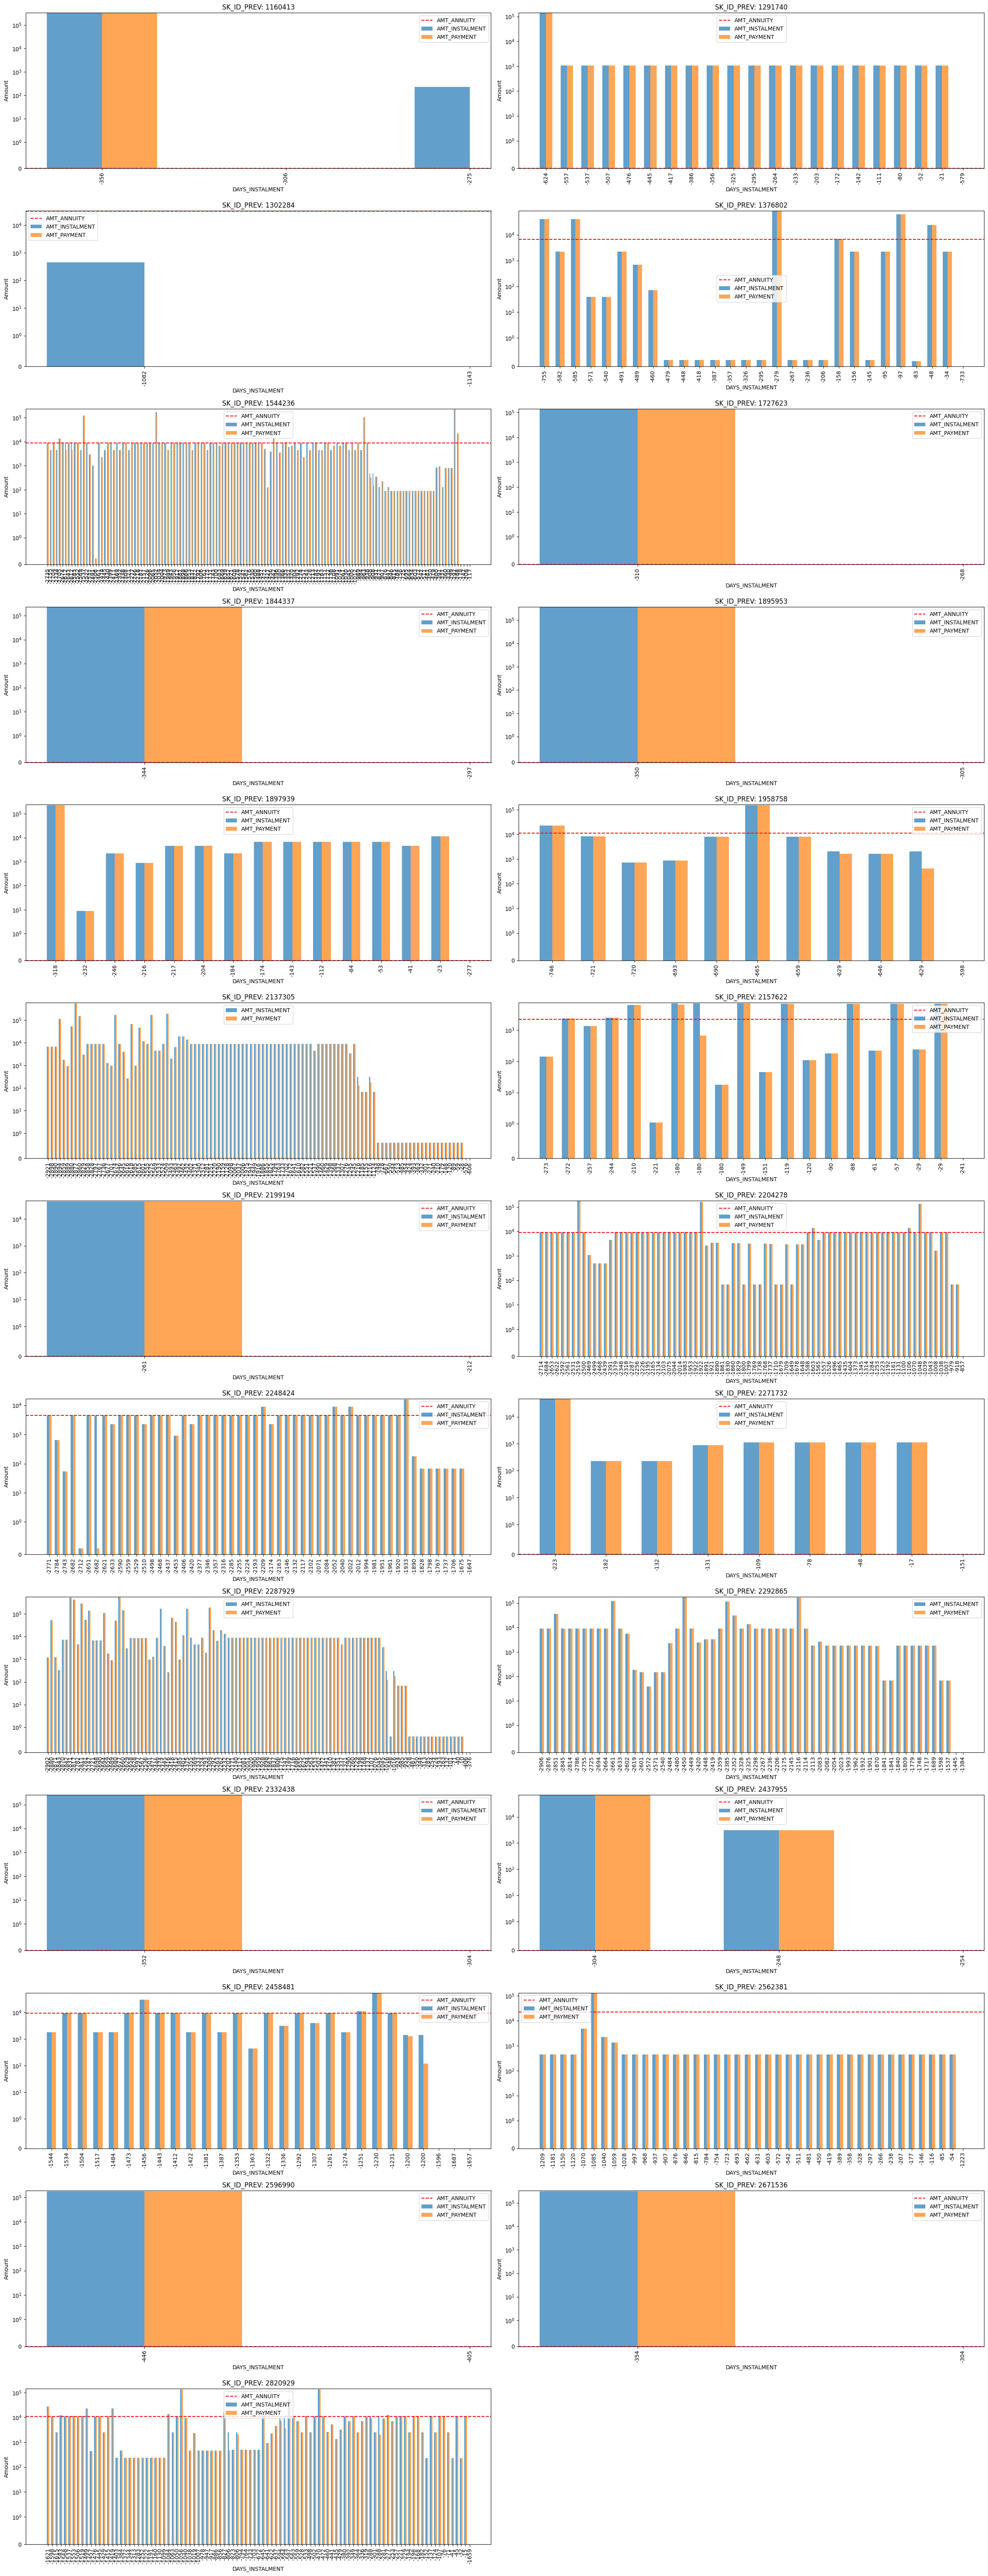

In [83]:
unique_ids = merged_df[merged_df["NUM_INSTALMENT_VERSION"] == 0]["SK_ID_PREV"].unique()
n_ids = len(unique_ids)

n_cols = 2
n_rows = int(np.ceil(n_ids / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5 * n_rows))
axes = axes.flatten()

for i, sk_id in enumerate(unique_ids):
    sub_df = merged_df[merged_df["SK_ID_PREV"] == sk_id]

    ax = axes[i]
    x = np.arange(len(sub_df["DAYS_INSTALMENT"]))
    width = 0.3

    ax.bar(x - width / 2, sub_df["AMT_INSTALMENT"], width=width, label="AMT_INSTALMENT", alpha=0.7)
    ax.bar(x + width / 2, sub_df["AMT_PAYMENT"], width=width, label="AMT_PAYMENT", alpha=0.7)

    if not sub_df["AMT_ANNUITY"].isnull().all():
        annuity_value = sub_df["AMT_ANNUITY"].iloc[0]
        ax.axhline(y=annuity_value, color="red", linestyle="--", label="AMT_ANNUITY")

    ax.set_xticks(x)
    ax.set_xticklabels(sub_df["DAYS_INSTALMENT"], rotation=90)

    ax.set_xlabel("DAYS_INSTALMENT")
    ax.set_ylabel("Amount")
    ax.set_yscale("symlog", linthresh=1)  # scale log
    ax.set_title(f"SK_ID_PREV: {sk_id}")
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig)
view.html_view_image(buf)


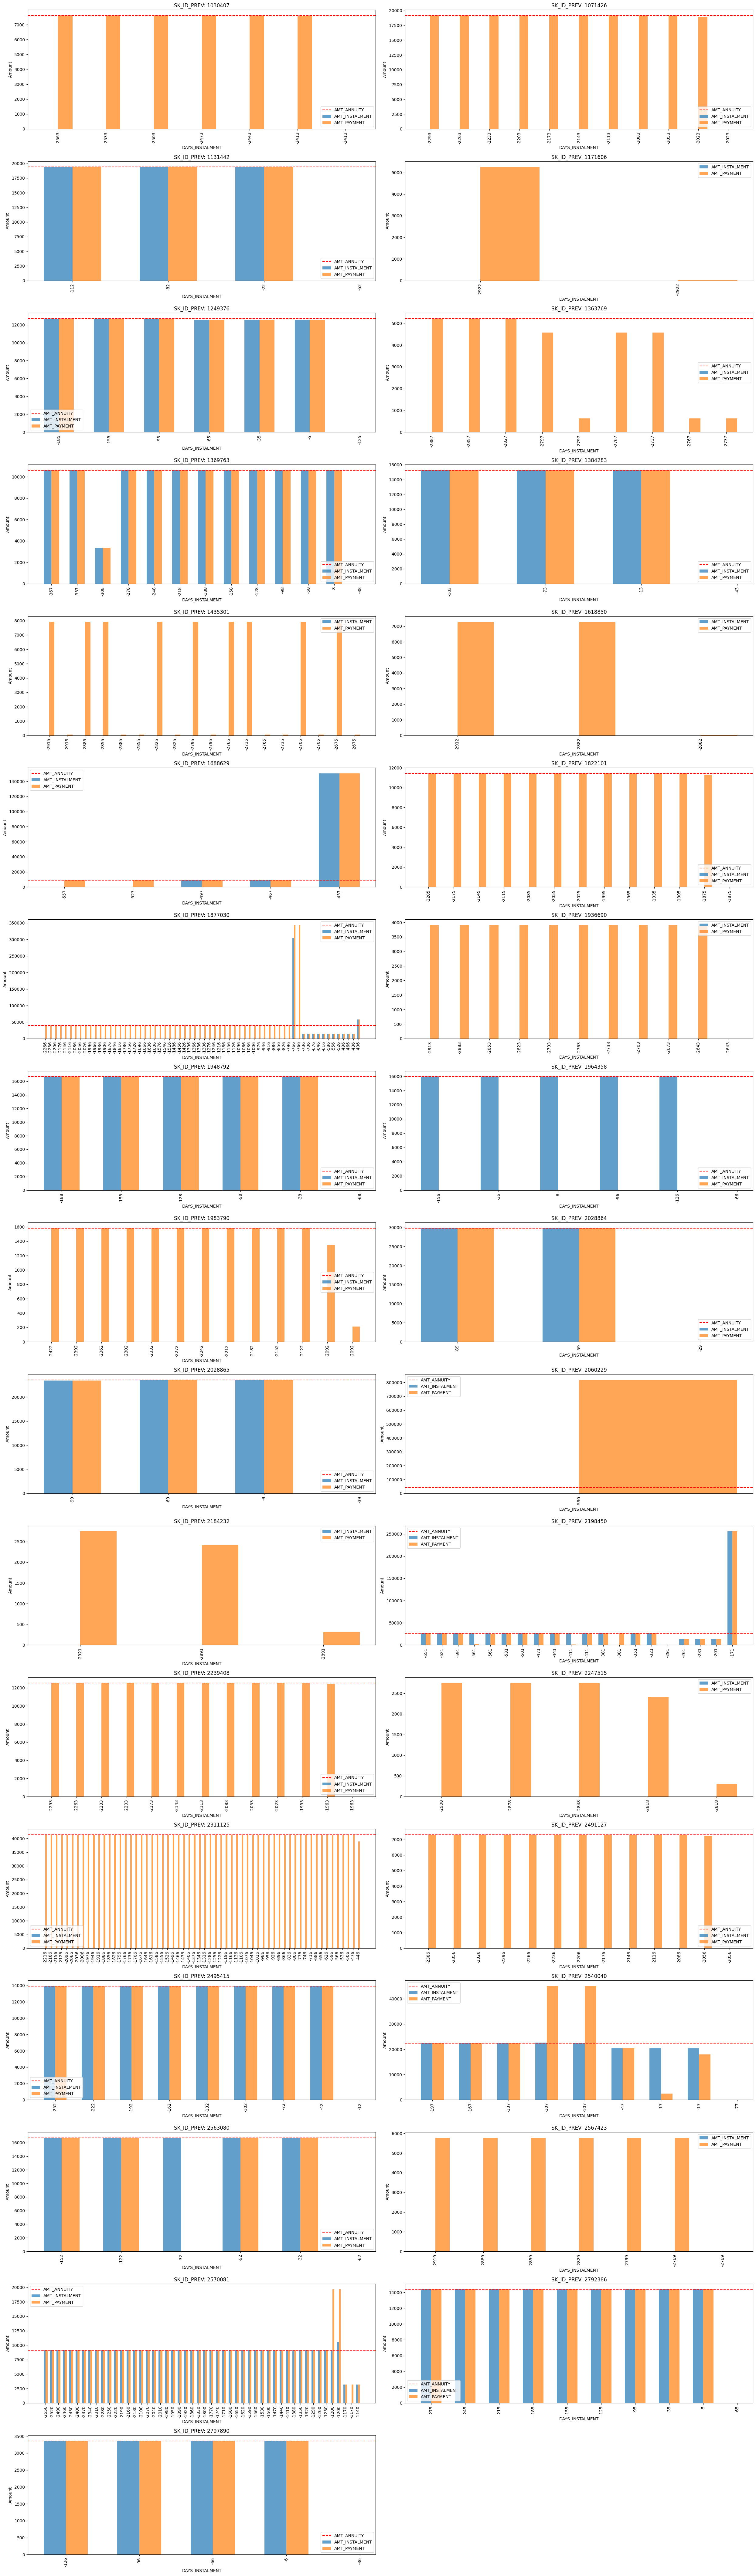

In [84]:
unique_ids = merged_df[merged_df["NUM_INSTALMENT_VERSION"] != 0]["SK_ID_PREV"].unique()
n_ids = len(unique_ids)
n_cols = 2
n_rows = int(np.ceil(n_ids / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5 * n_rows))
axes = axes.flatten()
for i, sk_id in enumerate(unique_ids):
    sub_df = merged_df[merged_df["SK_ID_PREV"] == sk_id]

    ax = axes[i]
    x = np.arange(len(sub_df["DAYS_INSTALMENT"]))
    width = 0.3

    ax.bar(x - width / 2, sub_df["AMT_INSTALMENT"], width=width, label="AMT_INSTALMENT", alpha=0.7)
    ax.bar(x + width / 2, sub_df["AMT_PAYMENT"], width=width, label="AMT_PAYMENT", alpha=0.7)
    if not sub_df["AMT_ANNUITY"].isnull().all():
        annuity_value = sub_df["AMT_ANNUITY"].iloc[0]
        ax.axhline(y=annuity_value, color="red", linestyle="--", label="AMT_ANNUITY")

    ax.set_xticks(x)
    ax.set_xticklabels(sub_df["DAYS_INSTALMENT"], rotation=90)

    ax.set_xlabel("DAYS_INSTALMENT")
    ax.set_ylabel("Amount")
    # ax.set_yscale("symlog", linthresh=1)
    ax.set_title(f"SK_ID_PREV: {sk_id}")
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig)
view.html_view_image(buf)

các trường hợp có thể khiến AMT_INSTALMENT = 0 hoặc null (AMT_INSTALMENT là khoản trả góp định kỳ) [ta liên hệ với cả các lần trả góp liên quan tới khoản vay chứa INSTALMENT = 0]:
* Miss value. Có thể fill bằng cách join từ prev.AMT_ANNUITY, nhưng cần đề phòng: 
* * trường hợp trả nhiều hơn định kỳ khiến các kỳ sang INSTALMENT giảm xuống ; 
* * thay đổi parameter version khoản vay khiến INSTALMENT thay đổi ; 
* * khoản vay không tồn tại thông tin trong prev
* Các khoản vay tín dụng:
* * prev_ANNUITY = 0 hoặc null, CNT_PAYMENT = 0 (số tháng trả góp theo lý thuyết). Có thể tín dụng không hạn mức? Trong trường hợp này, khoản trả góp định kỳ không cố định (vì liên hệ tới các tháng khác của khoản vay đó, ta thấy có những INSTALMENT và PAYMENT không cố định). Thêm nữa, bộ dữ liệu Home Credit đa phân thu thập từ khu vực ĐNÁ, nơi mà khái niệm tín dụng kiểu này không phổ biến, dẫn đến phân bổ tín dụng không đều (có tháng rất nhiều, có tháng rất ít)
* * prev_ANNUITY > 0. Ta thấy người dùng có xu hướng sử dụng INSTALMENT (số tiền tín dụng phải trả) ~ ANNUITY (Sử dụng tín dụng dưới hạn mức dẫn đến chỉ phải trả lãi suất tối thiểu. Mặc dù vẫn có những tháng vượt hạn mức nhưng thưa thớt)
* Các khoản vay khác (version != 0):
* * (trục x xét theo DAYS_INSTALMENT nên sẽ có trường hợp thanh toán nhiều hơn 1 lần cho một khoản trả góp định kỳ của tháng đó, nếu sum group sẽ nhận được đủ số tiền)
* * Có xu hướng thanh toán đồng đều (giữa các tháng hoặc với ANNUITY) trả góp hơn vay tín dụng. Vì là các khoản vay tiêu dùng trả góp, giá trị PAYMENT đều đặn đó rất có thể là INSTALMENT. Mặt khác ta thấy sự thiếu hụt của AMT_INSTALMENT ==> AMT_INSTALMENT của các khoản vay khác chính là missing value, ta fill bằng ANNUITY trong trường hợp có AMT_PAYMENT
* * Có 2 xu hướng chính: đều đặn hoặc trả vượt mức trả góp để giảm thời gian và lãi suất

* AMT_PAYMENT = 0 hoặc null cũng có thể khiến AMT_INSTALMENT = 0 hoặc null

In [85]:
### fill nan

median_instalment = merged_df.groupby("SK_ID_PREV")["AMT_INSTALMENT"].transform("median")

payment_sum = merged_df.groupby(["SK_ID_PREV", "NUM_INSTALMENT_NUMBER"])["AMT_PAYMENT"].sum()  # vì có nhiều lần trả cho một INSTALMENT nên lấy sum
median_payment = merged_df["SK_ID_PREV"].map(payment_sum.groupby("SK_ID_PREV").median())
median_annuity = pd.Series(
    np.where(
        (median_instalment == 0) | median_instalment.isna(),  # annuity = null => lấy trung vị instalment => instalment = null lấy trung vị payment
        median_payment,
        median_instalment
    ),
    index=merged_df.index
)
merged_df["AMT_ANNUITY"] = merged_df["AMT_ANNUITY"].fillna(median_annuity)

mask = (merged_df["NUM_INSTALMENT_VERSION"] != 0) & (merged_df["AMT_PAYMENT"] > 0)  # chỉ lấy những bản ghi có PAYMENT
merged_df.loc[mask, "AMT_INSTALMENT"] = merged_df.loc[mask, "AMT_INSTALMENT"].replace(0, np.nan)
merged_df["AMT_INSTALMENT"] = merged_df["AMT_INSTALMENT"].fillna(merged_df["AMT_ANNUITY"])


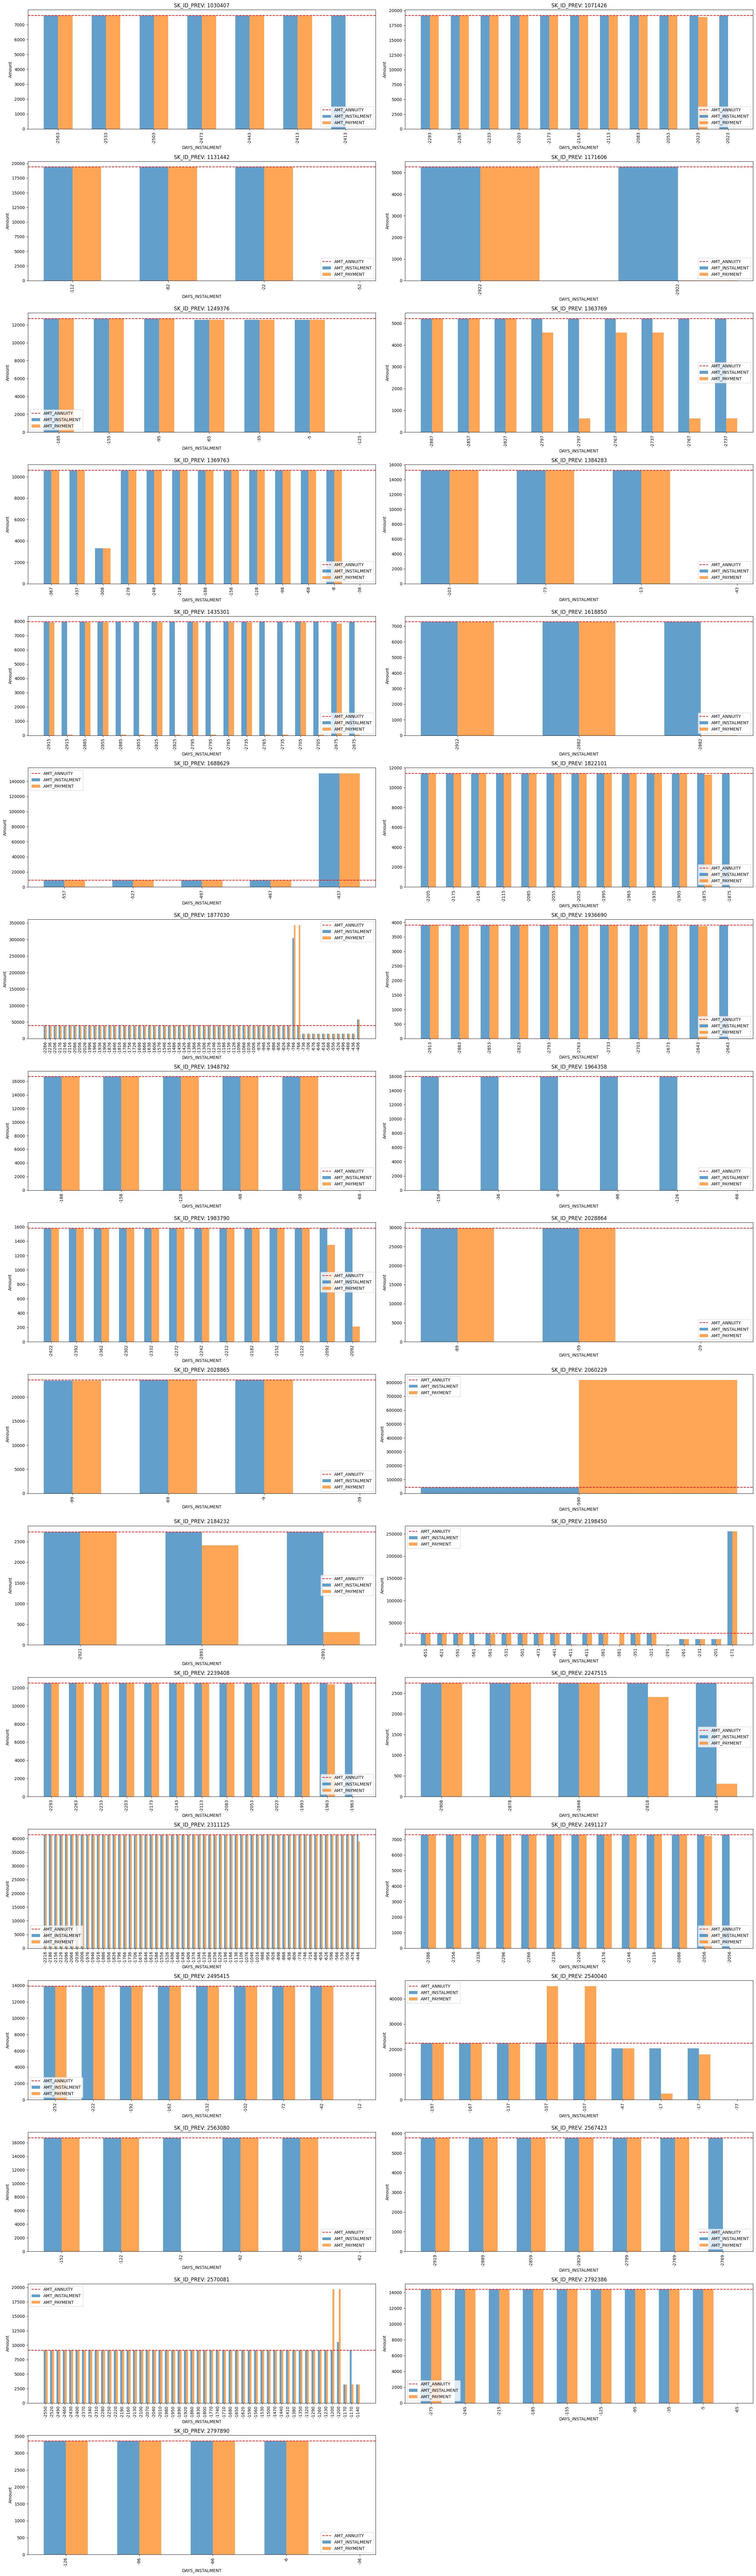

In [86]:
unique_ids = merged_df[merged_df["NUM_INSTALMENT_VERSION"] != 0]["SK_ID_PREV"].unique()
n_ids = len(unique_ids)
n_cols = 2
n_rows = int(np.ceil(n_ids / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5 * n_rows))
axes = axes.flatten()
for i, sk_id in enumerate(unique_ids):
    sub_df = merged_df[merged_df["SK_ID_PREV"] == sk_id]

    ax = axes[i]
    x = np.arange(len(sub_df["DAYS_INSTALMENT"]))
    width = 0.3

    ax.bar(x - width / 2, sub_df["AMT_INSTALMENT"], width=width, label="AMT_INSTALMENT", alpha=0.7)
    ax.bar(x + width / 2, sub_df["AMT_PAYMENT"], width=width, label="AMT_PAYMENT", alpha=0.7)
    if not sub_df["AMT_ANNUITY"].isnull().all():
        annuity_value = sub_df["AMT_ANNUITY"].iloc[0]
        ax.axhline(y=annuity_value, color="red", linestyle="--", label="AMT_ANNUITY")

    ax.set_xticks(x)
    ax.set_xticklabels(sub_df["DAYS_INSTALMENT"], rotation=90)

    ax.set_xlabel("DAYS_INSTALMENT")
    ax.set_ylabel("Amount")
    # ax.set_yscale("symlog", linthresh=1)
    ax.set_title(f"SK_ID_PREV: {sk_id}")
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig)
view.html_view_image(buf)

In [87]:
merged_df = merged_df.rename(columns={"AMT_INSTALMENT": "filled_AMT_INSTALMENT"})  # đổi tên cột và index thành cột

In [88]:
merged_df[merged_df["NUM_INSTALMENT_VERSION"] != 0][["index", "SK_ID_PREV", "filled_AMT_INSTALMENT"]]

,index,SK_ID_PREV,filled_AMT_INSTALMENT
0,265051,1030407,7616.655
1,265052,1030407,7616.655
2,265053,1030407,7616.655
3,265054,1030407,7616.655
4,265055,1030407,7616.655
...,...,...,...
1160,13269555,2797890,3356.865
1161,13269556,2797890,3356.865
1162,13269557,2797890,3356.865
1163,13269558,2797890,3356.865


In [89]:
tmp = tmp.merge(merged_df[merged_df["NUM_INSTALMENT_VERSION"] != 0][["index", "SK_ID_PREV", "filled_AMT_INSTALMENT"]], on=["index", "SK_ID_PREV"], how="left")

In [90]:
tmp.shape  # oke

(13605401, 10)

In [91]:
tmp.loc[~tmp["filled_AMT_INSTALMENT"].isnull(), "AMT_INSTALMENT"] = tmp["filled_AMT_INSTALMENT"]

In [92]:
tmp = tmp.drop(["filled_AMT_INSTALMENT"], axis=1)

In [93]:
view.html_view(tmp[tmp["AMT_INSTALMENT"] == 0])

index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
1045323,1131442,130761,2.0,3,-52,NaN,0.0,NaN
1279965,1160413,162504,0.0,2,-306,NaN,0.0,NaN
1945129,1249376,398830,2.0,3,-125,NaN,0.0,NaN
2298031,1291740,288884,0.0,2,-579,NaN,0.0,NaN
2363199,1302284,168183,0.0,1,-1143,NaN,0.0,NaN
2904956,1369763,380807,3.0,12,-38,NaN,0.0,NaN
2958503,1376802,104523,0.0,2,-733,NaN,0.0,NaN
3022628,1384283,153840,2.0,3,-43,NaN,0.0,NaN
4264477,1544236,403907,0.0,137,-178,NaN,0.0,NaN
4264478,1544236,403907,0.0,138,-147,NaN,0.0,NaN


In [94]:
cache_clear()

## AMT_PAYMENT

In [95]:
view.html_view(tmp[((tmp["AMT_PAYMENT"].isnull()) | (tmp["AMT_PAYMENT"] == 0))])

index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
8983,1000841,198725,0.0,29,-2271,-2298.0,9000.000,0.0
9383,1000847,389124,0.0,3,-2301,-2330.0,9000.000,0.0
10353,1000857,373592,0.0,4,-2445,-2471.0,6750.000,0.0
21088,1001758,122569,0.0,8,-2402,-2432.0,1890.000,0.0
21106,1001758,122569,0.0,27,-1825,NaN,67.500,NaN
21107,1001758,122569,0.0,25,-1884,NaN,67.500,NaN
21108,1001758,122569,0.0,26,-1853,NaN,67.500,NaN
21109,1001758,122569,0.0,24,-1915,NaN,96.435,NaN
38817,1003474,310842,0.0,9,-96,NaN,130.500,NaN
47144,1004174,284523,2.0,101,-2387,NaN,1350.000,NaN


# feature engineering

In [96]:
tmp["days_delayed_payment"] = tmp["DAYS_ENTRY_PAYMENT"] - tmp["DAYS_INSTALMENT"]

tmp["AMT_PAYMENT-s-AMT_INSTALMENT"] = tmp["AMT_PAYMENT"] - tmp["AMT_INSTALMENT"]  # chênh lệch giữa số tiền trả thực tế và số tiền phải trả theo quy định
tmp["AMT_PAYMENT-d-AMT_INSTALMENT"] = tmp["AMT_PAYMENT"] / tmp["AMT_INSTALMENT"]  # tỉ lệ giữa số tiền trả thực tế và số tiền phải trả theo quy định

tmp["days_weighted_delayed_payment"] = tmp["days_delayed_payment"] * tmp["AMT_PAYMENT-d-AMT_INSTALMENT"]  # delay trả góp * tỉ lệ trả đủ (trọng số)
tmp["days_weighted_delay_tsw3"] = tmp['days_weighted_delayed_payment'] * (1 + (tmp['DAYS_ENTRY_PAYMENT'] * 0.0003))  # time series weight decay = 0.0003

# Days past due and days before due (không lấy giá trị âm)
tmp['DPD'] = tmp['DAYS_ENTRY_PAYMENT'] - tmp['DAYS_INSTALMENT']
tmp['DBD'] = tmp['DAYS_INSTALMENT'] - tmp['DAYS_ENTRY_PAYMENT']
tmp['DPD'] = tmp['DPD'].apply(lambda x: x if x > 0 else 0)
tmp['DBD'] = tmp['DBD'].apply(lambda x: x if x > 0 else 0)

In [97]:
view.html_view(tmp.head(100))

index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,days_delayed_payment,AMT_PAYMENT-s-AMT_INSTALMENT,AMT_PAYMENT-d-AMT_INSTALMENT,days_weighted_delayed_payment,days_weighted_delay_tsw3,DPD,DBD
0,1000001,158271,1.0,1,-268,-294.0,6404.310,6404.310,-26.0,0.000,1.00000,-26.000000,-23.706800,0.0,26.0
1,1000001,158271,2.0,2,-238,-244.0,62039.115,62039.115,-6.0,0.000,1.00000,-6.000000,-5.560800,0.0,6.0
2,1000002,101962,1.0,1,-1600,-1611.0,6264.000,6264.000,-11.0,0.000,1.00000,-11.000000,-5.683700,0.0,11.0
3,1000002,101962,1.0,2,-1570,-1575.0,6264.000,6264.000,-5.0,0.000,1.00000,-5.000000,-2.637500,0.0,5.0
4,1000002,101962,1.0,3,-1540,-1559.0,6264.000,6264.000,-19.0,0.000,1.00000,-19.000000,-10.113700,0.0,19.0
5,1000002,101962,2.0,4,-1510,-1554.0,18443.565,18443.565,-44.0,0.000,1.00000,-44.000000,-23.487200,0.0,44.0
6,1000003,252457,1.0,1,-94,-108.0,4951.350,4951.350,-14.0,0.000,1.00000,-14.000000,-13.546400,0.0,14.0
7,1000003,252457,1.0,2,-64,-81.0,4951.350,4951.350,-17.0,0.000,1.00000,-17.000000,-16.586900,0.0,17.0
8,1000003,252457,1.0,3,-34,-49.0,4951.350,4951.350,-15.0,0.000,1.00000,-15.000000,-14.779500,0.0,15.0
9,1000004,260094,1.0,1,-862,-881.0,3391.110,3391.110,-19.0,0.000,1.00000,-19.000000,-13.978300,0.0,19.0


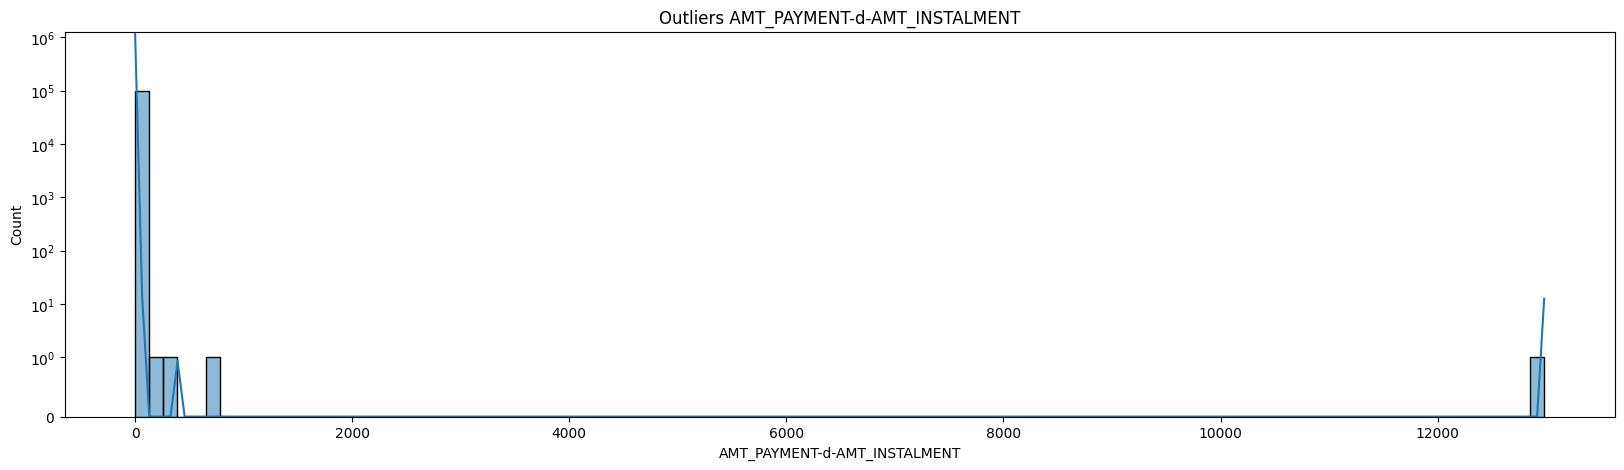

In [98]:
plt.figure(figsize=(20, 5))
sns.histplot(tmp["AMT_PAYMENT-d-AMT_INSTALMENT"].sample(n=100000), bins=100, kde=True)
plt.yscale("symlog", linthresh=1)  # loga tần suất
plt.title("Outliers AMT_PAYMENT-d-AMT_INSTALMENT")
plt.show()

In [99]:
tmp["AMT_PAYMENT-d-AMT_INSTALMENT"].max()  # max PAYMENT/INSTALMENT

np.float64(194250.0)

In [100]:
tmp[tmp["SK_ID_PREV"] == 1720477]

,index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,days_delayed_payment,AMT_PAYMENT-s-AMT_INSTALMENT,AMT_PAYMENT-d-AMT_INSTALMENT,days_weighted_delayed_payment,days_weighted_delay_tsw3,DPD,DBD
5558326,5558326,1720477,208684,2.0,1,-564,-566.0,0.090,17482.500,-2.0,17482.41,194250.000000,-388500.00000,-322532.700000,0.0,2.0
5558327,5558327,1720477,208684,1.0,1,-564,-566.0,17482.410,17482.500,-2.0,0.09,1.000005,-2.00001,-1.660409,0.0,2.0
5558328,5558328,1720477,208684,3.0,2,-534,-535.0,17482.410,17482.410,-1.0,0.00,1.000000,-1.00000,-0.839500,0.0,1.0
5558329,5558329,1720477,208684,3.0,3,-504,-511.0,17482.410,17482.410,-7.0,0.00,1.000000,-7.00000,-5.926900,0.0,7.0
5558330,5558330,1720477,208684,4.0,4,-474,-491.0,50522.085,50522.085,-17.0,0.00,1.000000,-17.00000,-14.495900,0.0,17.0


In [101]:
prev[prev["SK_ID_PREV"] == 1720477]

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,exist
94019,1720477,208684,Cash loans,17482.41,90000.0,92970.0,NaN,90000.0,FRIDAY,15,Y,1,NaN,NaN,NaN,XNA,Approved,-594,Cash through the bank,XAP,None,Refreshed,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,6.0,middle,Cash X-Sell: middle,365243.0,-564.0,-414.0,-474.0,-466.0,1.0,1


* trả nhiều số tiền định kỳ (mục đích là do đổi chỉ số khoản vay NUM_INSTALMENT_VERSION, trả nhiều hơn để giảm lãi suất, giảm số tháng vay lãi...)

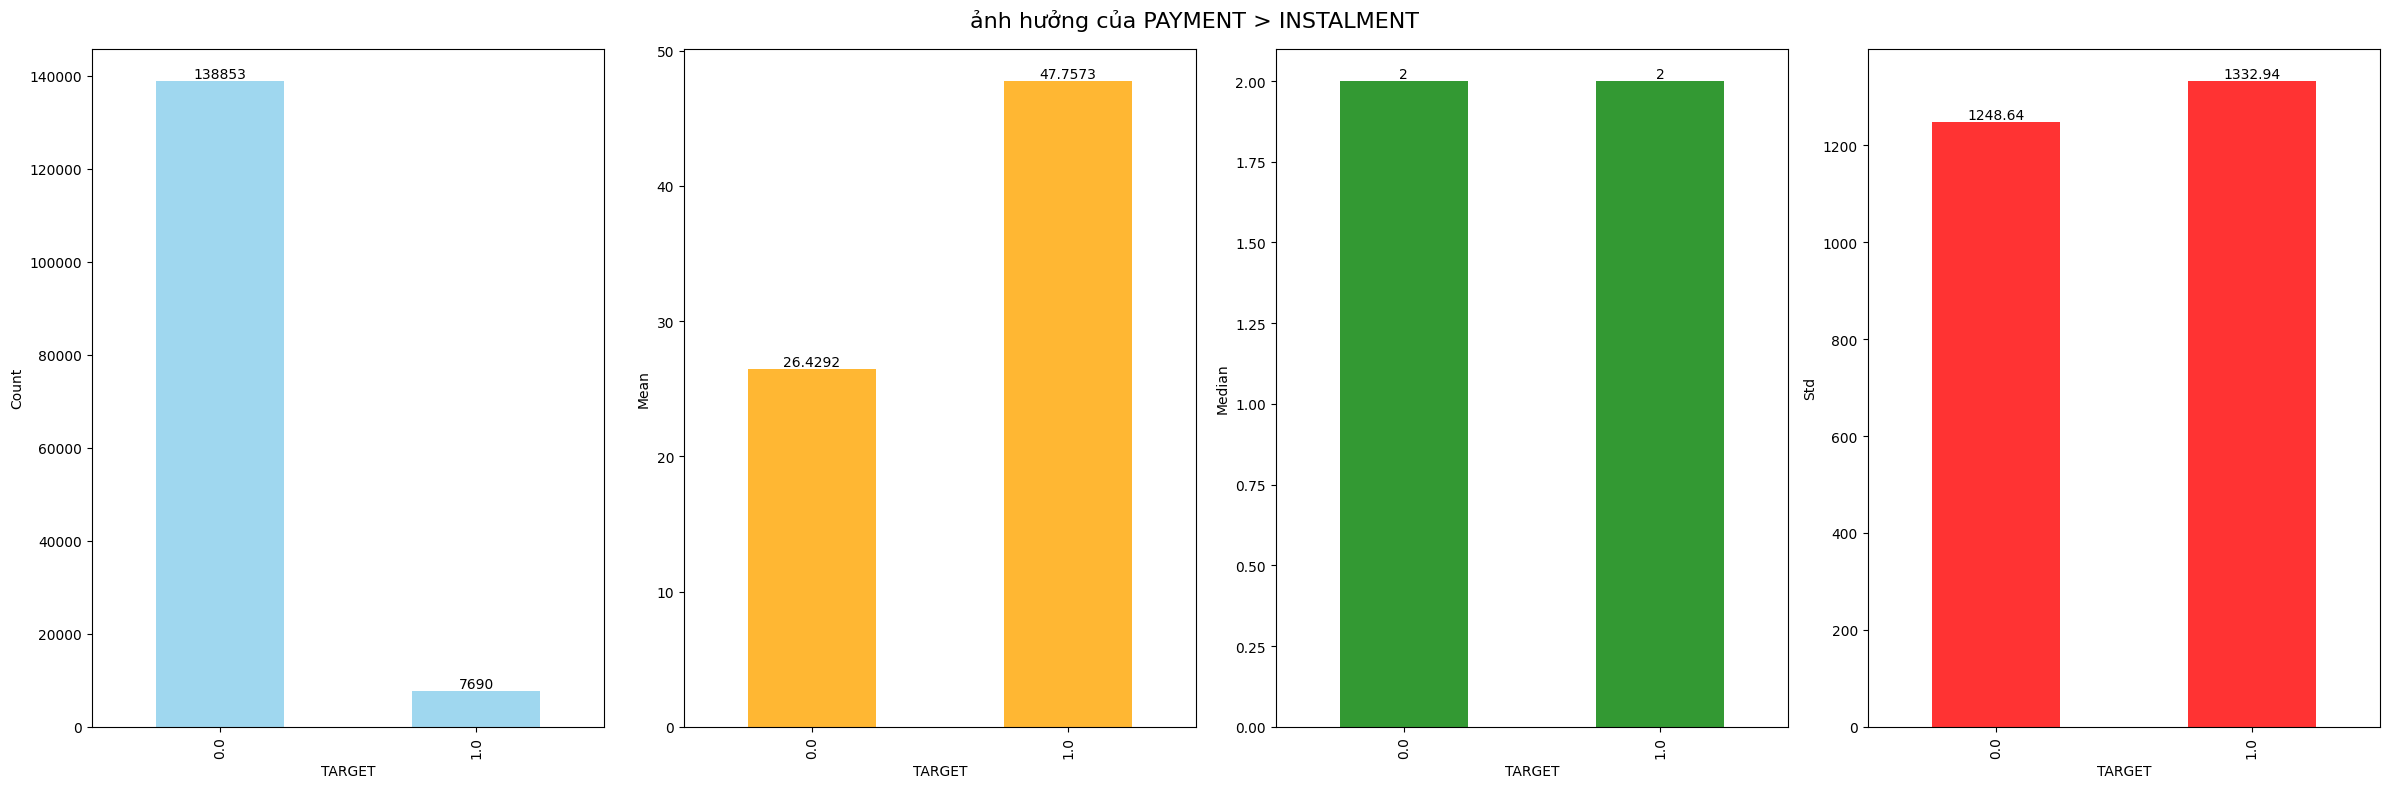

In [102]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8))
fig.suptitle("ảnh hưởng của PAYMENT > INSTALMENT", fontsize=16)

result = tmp[(tmp["AMT_PAYMENT-d-AMT_INSTALMENT"] > 1)].merge(train, on="SK_ID_CURR", how="left")
result.groupby("TARGET")["AMT_PAYMENT-d-AMT_INSTALMENT"].count().plot(kind="bar", ax=axes[0], color="skyblue", alpha=0.8)
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0])

result.groupby("TARGET")["AMT_PAYMENT-d-AMT_INSTALMENT"].mean().plot(kind="bar", ax=axes[1], color="orange", alpha=0.8)
axes[1].set_ylabel("Mean")
axes[1].bar_label(axes[1].containers[0])

result.groupby("TARGET")["AMT_PAYMENT-d-AMT_INSTALMENT"].median().plot(kind="bar", ax=axes[2], color="green", alpha=0.8)
axes[2].set_ylabel("Median")
axes[2].bar_label(axes[2].containers[0])

result.groupby("TARGET")["AMT_PAYMENT-d-AMT_INSTALMENT"].std().plot(kind="bar", ax=axes[3], color="red", alpha=0.8)
axes[3].set_ylabel("Std")
axes[3].bar_label(axes[3].containers[0])

plt.tight_layout()
plt.show()

* PAYMENT/INSTALMENT > 1 tồn tại giá trị lớn (outlier) ở hồ sơ rủi ro hơn. 
* Nhưng xu hướng như nhau (median)
* Dữ liệu ở nhóm này phân tán không đều

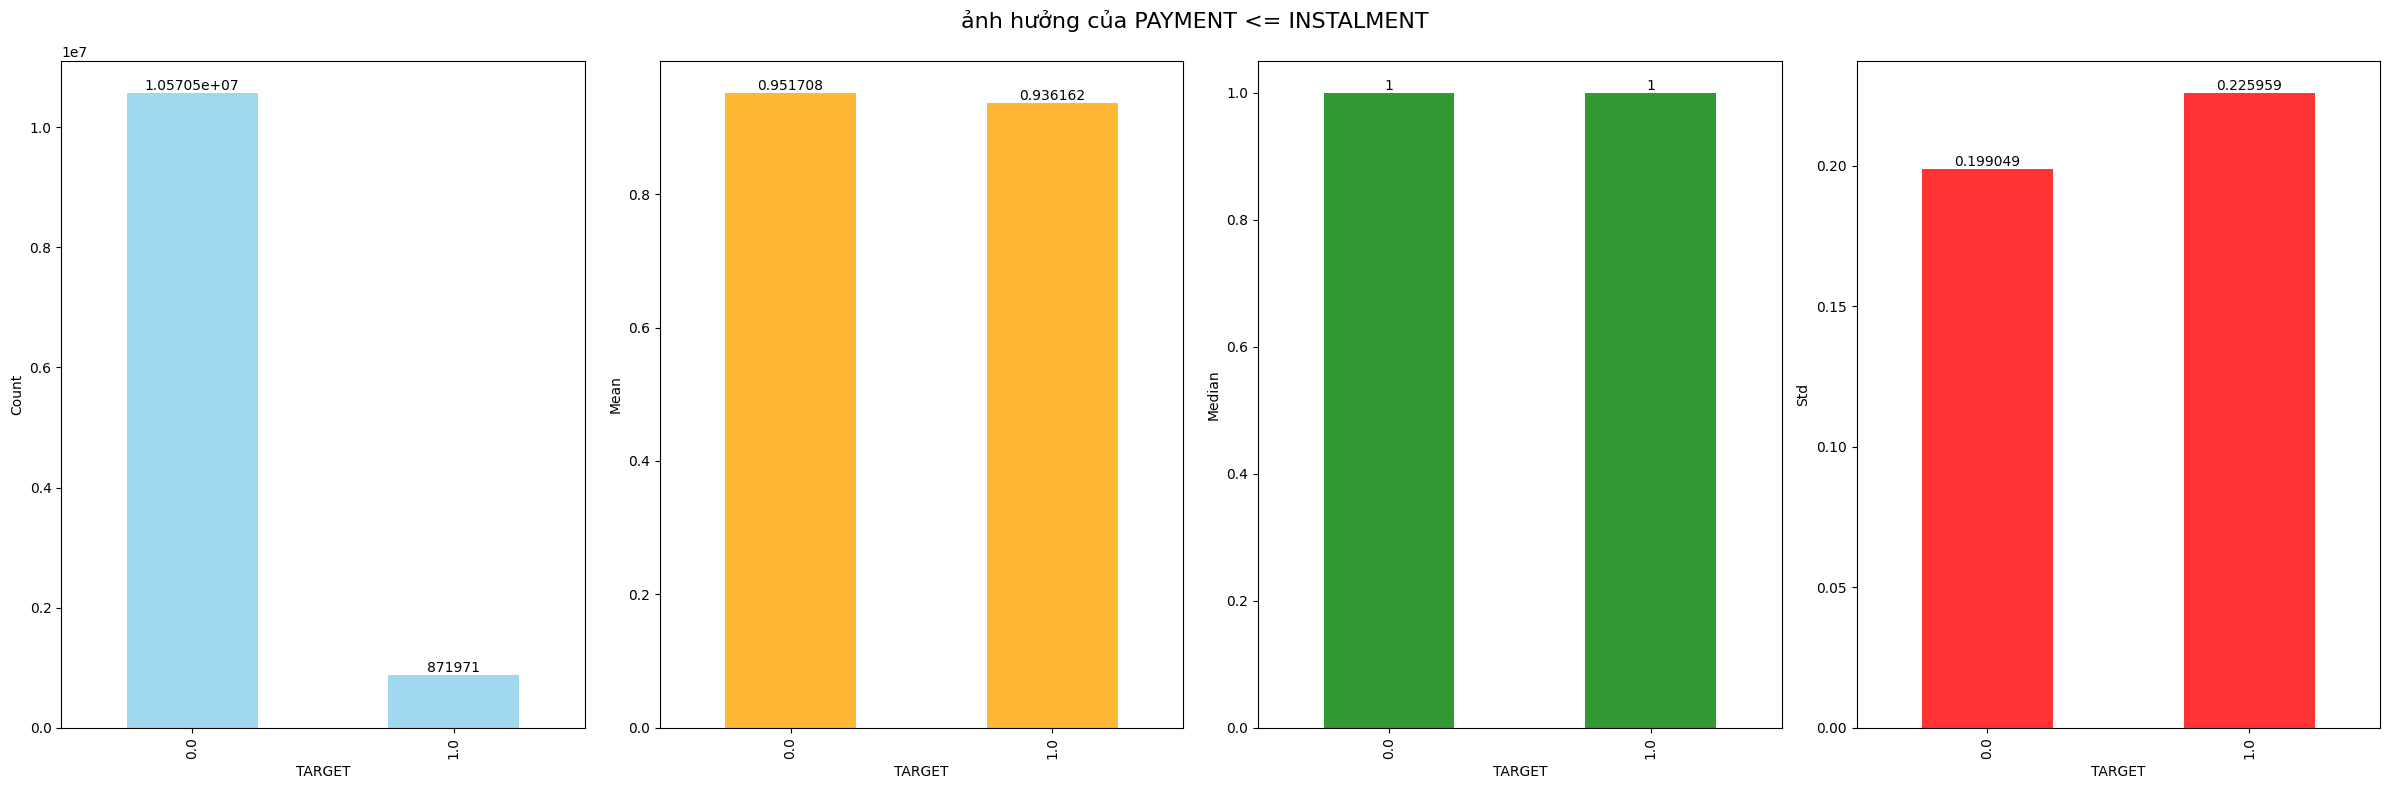

In [103]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8))
fig.suptitle("ảnh hưởng của PAYMENT <= INSTALMENT", fontsize=16)

result = tmp[(tmp["AMT_PAYMENT-d-AMT_INSTALMENT"] <= 1)].merge(train, on="SK_ID_CURR", how="left")
result.groupby("TARGET")["AMT_PAYMENT-d-AMT_INSTALMENT"].count().plot(kind="bar", ax=axes[0], color="skyblue", alpha=0.8)
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0])

result.groupby("TARGET")["AMT_PAYMENT-d-AMT_INSTALMENT"].mean().plot(kind="bar", ax=axes[1], color="orange", alpha=0.8)
axes[1].set_ylabel("Mean")
axes[1].bar_label(axes[1].containers[0])

result.groupby("TARGET")["AMT_PAYMENT-d-AMT_INSTALMENT"].median().plot(kind="bar", ax=axes[2], color="green", alpha=0.8)
axes[2].set_ylabel("Median")
axes[2].bar_label(axes[2].containers[0])

result.groupby("TARGET")["AMT_PAYMENT-d-AMT_INSTALMENT"].std().plot(kind="bar", ax=axes[3], color="red", alpha=0.8)
axes[3].set_ylabel("Std")
axes[3].bar_label(axes[3].containers[0])

plt.tight_layout()
plt.show()

In [104]:
cache_clear(globals(), _keep_vars)

# xét hồ sơ có hành vi trả góp nhiều lần cho 1 NUM_INSTALMENT_NUMBER

* curr_id = 176456 có 2 lần NUM_INSTALMENT_NUMBER = 9  
==>  tháng đó trả 2 lần, một lần thiếu nên trả thêm lần nữa, tổng số tiền 2 lần trả trong một instalment bằng số tiền phải trả định kỳ tháng đó.


(có nên group by NUM_INSTALMENT_NUMBER?)

## xét ratio = NUM_INSTALMENT_NUMBER / CNT_PAYMENT

In [105]:
prev[prev["SK_ID_CURR"] == 176456].head(5)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,exist
23289,1000005,176456,Consumer loans,14713.605,123486.075,120307.5,12349.575,123486.075,THURSDAY,13,Y,1,0.101388,NaN,NaN,XAP,Approved,-1719,Cash through the bank,XAP,Family,New,Construction Materials,POS,XNA,Stone,1877,Construction,10.0,middle,POS industry with interest,365243.0,-1688.0,-1418.0,-1418.0,-1415.0,0.0,1


In [106]:
tmp[tmp["SK_ID_CURR"] == 176456]

,index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,days_delayed_payment,AMT_PAYMENT-s-AMT_INSTALMENT,AMT_PAYMENT-d-AMT_INSTALMENT,days_weighted_delayed_payment,days_weighted_delay_tsw3,DPD,DBD
16,16,1000005,176456,1.0,1,-1688,-1687.0,14713.605,14713.605,1.0,0.000,1.00000,1.000000,0.493900,1.0,0.0
17,17,1000005,176456,1.0,2,-1658,-1664.0,14713.605,14713.605,-6.0,0.000,1.00000,-6.000000,-3.004800,0.0,6.0
18,18,1000005,176456,1.0,3,-1628,-1636.0,14713.605,14713.605,-8.0,0.000,1.00000,-8.000000,-4.073600,0.0,8.0
19,19,1000005,176456,1.0,4,-1598,-1606.0,14713.605,14713.605,-8.0,0.000,1.00000,-8.000000,-4.145600,0.0,8.0
20,20,1000005,176456,1.0,5,-1568,-1575.0,14713.605,14713.605,-7.0,0.000,1.00000,-7.000000,-3.692500,0.0,7.0
21,21,1000005,176456,1.0,6,-1538,-1545.0,14713.605,14713.605,-7.0,0.000,1.00000,-7.000000,-3.755500,0.0,7.0
22,22,1000005,176456,1.0,7,-1508,-1512.0,14713.605,14713.605,-4.0,0.000,1.00000,-4.000000,-2.185600,0.0,4.0
23,23,1000005,176456,1.0,8,-1478,-1484.0,14713.605,14713.605,-6.0,0.000,1.00000,-6.000000,-3.328800,0.0,6.0
24,24,1000005,176456,1.0,9,-1448,-1484.0,14713.605,2.790,-36.0,-14710.815,0.00019,-0.006826,-0.003787,0.0,36.0
25,25,1000005,176456,1.0,9,-1448,-1445.0,14713.605,14710.815,3.0,-2.790,0.99981,2.999431,1.699178,3.0,0.0


In [107]:
prev[prev["SK_ID_PREV"] == 2360056]

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,exist
38620,2360056,453103,Revolving loans,5625.0,0.0,112500.0,NaN,NaN,TUESDAY,18,Y,1,NaN,NaN,NaN,XAP,Approved,-2904,XNA,XAP,None,Repeater,XNA,Cards,x-sell,Stone,180,Consumer electronics,0.0,XNA,Card Street,-2886.0,-2825.0,365243.0,365243.0,365243.0,0.0,1


In [108]:
tmp[tmp["SK_ID_PREV"] == 2360056]

,index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,days_delayed_payment,AMT_PAYMENT-s-AMT_INSTALMENT,AMT_PAYMENT-d-AMT_INSTALMENT,days_weighted_delayed_payment,days_weighted_delay_tsw3,DPD,DBD
10141120,10141120,2360056,453103,0.0,1,-2825,-2853.0,5625.0,5625.0,-28.0,0.0,1.0,-28.0,-4.0348,0.0,28.0
10141121,10141121,2360056,453103,0.0,2,-2853,-2853.0,41175.0,41175.0,0.0,0.0,1.0,0.0,0.0000,0.0,0.0
10141122,10141122,2360056,453103,0.0,3,-2839,-2839.0,25650.0,25650.0,0.0,0.0,1.0,0.0,0.0000,0.0,0.0
10141123,10141123,2360056,453103,0.0,5,-2812,-2812.0,9225.0,9225.0,0.0,0.0,1.0,0.0,0.0000,0.0,0.0
10141124,10141124,2360056,453103,0.0,4,-2794,-2812.0,5625.0,5625.0,-18.0,0.0,1.0,-18.0,-2.8152,0.0,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10141408,10141408,2360056,453103,0.0,273,-147,-168.0,5625.0,5625.0,-21.0,0.0,1.0,-21.0,-19.9416,0.0,21.0
10141409,10141409,2360056,453103,0.0,274,-117,-128.0,5625.0,5625.0,-11.0,0.0,1.0,-11.0,-10.5776,0.0,11.0
10141410,10141410,2360056,453103,0.0,275,-86,-95.0,5625.0,5625.0,-9.0,0.0,1.0,-9.0,-8.7435,0.0,9.0
10141411,10141411,2360056,453103,0.0,276,-56,-73.0,5625.0,5625.0,-17.0,0.0,1.0,-17.0,-16.6277,0.0,17.0


In [109]:
# group by SK_ID_PREV sau đó group by NUM_INSTALMENT_NUMBER (1 INSTALMENT) và NUM_INSTALMENT_VERSION (VERSION thay đổi là do parameter thay đổi)
# tốn nhiều thời gian chạy

# file_path = ROOT + "/data/pkl/grouped_installments_payment_001.p"
# selected_groups = []
# for _, group in tmp.groupby("SK_ID_PREV"):
#     # if group["NUM_INSTALMENT_NUMBER"].max() != group["NUM_INSTALMENT_NUMBER"].count():  # tìm các lần trả > 1 lần cho cùng NUM_INSTALMENT_NUMBER
#     grouped = group.groupby(["NUM_INSTALMENT_NUMBER", "NUM_INSTALMENT_VERSION"]).agg({
#         "SK_ID_PREV": "first",
#         "SK_ID_CURR": "first",
#         "DAYS_INSTALMENT": "first",
#         "AMT_INSTALMENT": "first",
#         "DAYS_ENTRY_PAYMENT": ["min", "max"],  # lấy ngày sớm và muộn nhất
#         "AMT_PAYMENT": "sum",
#         "AMT_PAYMENT-d-AMT_INSTALMENT": "var", # phương sai (độ ổn định tỉ lệ của mỗi lần trả góp cho tháng đó. nếu tháng đó chỉ có 1 lần trả thì bằng null)
#         "AMT_PAYMENT-s-AMT_INSTALMENT": "var", # phương sai,
#         "days_delayed_payment": ["mean", "max"], # lấy trung bình và max ngày delay
#         "days_not_delayed_payment": ["mean", "max"],
#         "days_weighted_delayed_payment": "mean",
#     }).reset_index()

#     # đổi tên cột
#     grouped.columns = [
#         "NUM_INSTALMENT_NUMBER", "NUM_INSTALMENT_VERSION", "SK_ID_PREV", "SK_ID_CURR",
#         "DAYS_INSTALMENT", "AMT_INSTALMENT", "DAYS_ENTRY_PAYMENT_min", "DAYS_ENTRY_PAYMENT_max", "AMT_PAYMENT",
#         "AMT_PAYMENT-d-AMT_INSTALMENT_var", "AMT_PAYMENT-s-AMT_INSTALMENT_var", "days_delayed_payment_mean", "days_delayed_payment_max", "days_not_delayed_payment_mean", "days_not_delayed_payment_max", "days_weighted_delayed_payment_mean"
#     ]

#     # # Tạo các cột mới
#     grouped["NUM_INSTALMENT_NUMBER_count"] = group.groupby(["NUM_INSTALMENT_NUMBER", "NUM_INSTALMENT_VERSION"]).size().values # thêm cột count để đếm số lần trả cho INSTALMENT_NUMBER đó tránh mất thông tin
#     grouped["DAYS_ENTRY_PAYMENT_period"] = grouped["DAYS_ENTRY_PAYMENT_max"] - grouped["DAYS_ENTRY_PAYMENT_min"] # thêm cột khoảng thời gian từ lần đầu tới lần cuối của INSTALMENT_NUMBER đó
#     grouped["AMT_PAYMENT-d-AMT_INSTALMENT"] = grouped["AMT_PAYMENT"] / grouped["AMT_INSTALMENT"]
#     grouped["AMT_PAYMENT-s-AMT_INSTALMENT"] = grouped["AMT_PAYMENT"] - grouped["AMT_INSTALMENT"]

#     grouped = grouped.drop(columns=["DAYS_ENTRY_PAYMENT_max", "DAYS_ENTRY_PAYMENT_min"])

#     selected_groups.append(grouped)

#     if len(selected_groups) == 100:
#         if os.path.exists(file_path):
#             old_data = pd.read_pickle(file_path)
#             tmp_grouped = pd.concat([old_data] + selected_groups, ignore_index=True)
#         else:
#             tmp_grouped = pd.concat(selected_groups, ignore_index=True)

#         tmp_grouped.to_pickle(file_path)  # ghi đè lại file
#         selected_groups.clear()
#         print("100 grouped")

In [110]:
prev['CNT_PAYMENT'].replace(0, np.nan, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_304\1137191341.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prev['CNT_PAYMENT'].replace(0, np.nan, inplace=True)


In [111]:
tmp = tmp.merge(prev[["SK_ID_PREV", "CNT_PAYMENT"]], on="SK_ID_PREV", how='left')

In [112]:
# engineering

tmp["NUM_INSTALMENT_ratio"] = tmp["NUM_INSTALMENT_NUMBER"] / tmp["CNT_PAYMENT"]

In [113]:
view.html_view(tmp[tmp["NUM_INSTALMENT_ratio"] > 1].head(100))

index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,days_delayed_payment,AMT_PAYMENT-s-AMT_INSTALMENT,AMT_PAYMENT-d-AMT_INSTALMENT,days_weighted_delayed_payment,days_weighted_delay_tsw3,DPD,DBD,CNT_PAYMENT,NUM_INSTALMENT_ratio
473,1000055,238221,2.0,101,-1005,-991.0,3600.000,3600.000,14.0,0.000,1.000000,14.000000,9.837800,14.0,0.0,10.0,10.100000
1175,1000114,181665,2.0,101,-1730,-1721.0,3600.000,3600.000,9.0,0.000,1.000000,9.000000,4.353300,9.0,0.0,6.0,16.833333
1928,1000210,314456,2.0,101,-1014,-1011.0,1350.000,10.035,3.0,-1339.965,0.007433,0.022300,0.015536,3.0,0.0,24.0,4.208333
1939,1000210,314456,3.0,102,-895,-824.0,1350.000,1350.000,71.0,0.000,1.000000,71.000000,53.448800,71.0,0.0,24.0,4.250000
1940,1000210,314456,4.0,103,-865,-824.0,1350.000,1350.000,41.0,0.000,1.000000,41.000000,30.864800,41.0,0.0,24.0,4.291667
1942,1000210,314456,2.0,101,-1014,-824.0,1350.000,1339.965,190.0,-10.035,0.992567,188.587667,141.968795,190.0,0.0,24.0,4.208333
1957,1000210,314456,5.0,104,-624,-555.0,1350.000,1350.000,69.0,0.000,1.000000,69.000000,57.511500,69.0,0.0,24.0,4.333333
1958,1000210,314456,7.0,106,-565,-555.0,1350.000,1350.000,10.0,0.000,1.000000,10.000000,8.335000,10.0,0.0,24.0,4.416667
1960,1000210,314456,6.0,105,-595,-555.0,1350.000,1350.000,40.0,0.000,1.000000,40.000000,33.340000,40.0,0.0,24.0,4.375000
1964,1000210,314456,8.0,107,-505,-461.0,1350.000,1350.000,44.0,0.000,1.000000,44.000000,37.914800,44.0,0.0,24.0,4.458333


* Đặc điểm chung của những khoản trả góp nằm ngoài CNT_PAYMENT ban đầu là do version > 1, tức là có sự thay đổi về parameter khoản vay
* Đối với sự thay đổi về parameter khoản vay (NUM_INSTALMENT_VERSION thay đổi), sẽ có rất nhiều yếu tố có thể bị thay đổi: 
* * NUM_INSTALMET_NUMBER có thể trở thành 10x (101, 102...)
* * Số tiền phải trả góp định kỳ thay đổi
* * Thời gian trả góp thay đổi
* * ...
* Các khoản trả góp AMT_PAYMENT-d-AMT_INSTALMENT <= 1

In [114]:
tmp[tmp["SK_ID_PREV"] == 1017925]

,index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,days_delayed_payment,AMT_PAYMENT-s-AMT_INSTALMENT,AMT_PAYMENT-d-AMT_INSTALMENT,days_weighted_delayed_payment,days_weighted_delay_tsw3,DPD,DBD,CNT_PAYMENT,NUM_INSTALMENT_ratio
176551,176551,1017925,157904,1.0,5,-2720,-2850.0,3881.610,32.040,-130.0,-3849.570,0.008254,-1.073060,-0.155594,0.0,130.0,10.0,0.5
176552,176552,1017925,157904,1.0,4,-2750,-2850.0,3881.610,3881.610,-100.0,0.000,1.000000,-100.000000,-14.500000,0.0,100.0,10.0,0.4
176553,176553,1017925,157904,1.0,1,-2840,-2840.0,3881.610,3881.610,0.0,0.000,1.000000,0.000000,0.000000,0.0,0.0,10.0,0.1
176554,176554,1017925,157904,1.0,2,-2810,-2810.0,3881.610,3881.610,0.0,0.000,1.000000,0.000000,0.000000,0.0,0.0,10.0,0.2
176555,176555,1017925,157904,1.0,3,-2780,-2780.0,3881.610,3881.610,0.0,0.000,1.000000,0.000000,0.000000,0.0,0.0,10.0,0.3
176556,176556,1017925,157904,1.0,5,-2720,-2717.0,3881.610,3849.570,3.0,-32.040,0.991746,2.975237,0.550121,3.0,0.0,10.0,0.5
176557,176557,1017925,157904,1.0,6,-2690,-2698.0,3881.610,3881.610,-8.0,0.000,1.000000,-8.000000,-1.524800,0.0,8.0,10.0,0.6
176558,176558,1017925,157904,1.0,7,-2660,-2698.0,3881.610,3881.610,-38.0,0.000,1.000000,-38.000000,-7.242800,0.0,38.0,10.0,0.7
176559,176559,1017925,157904,1.0,8,-2630,-2698.0,3881.610,37.710,-68.0,-3843.900,0.009715,-0.660623,-0.125915,0.0,68.0,10.0,0.8
176560,176560,1017925,157904,1.0,8,-2630,-2625.0,3881.610,3843.900,5.0,-37.710,0.990285,4.951425,1.052178,5.0,0.0,10.0,0.8


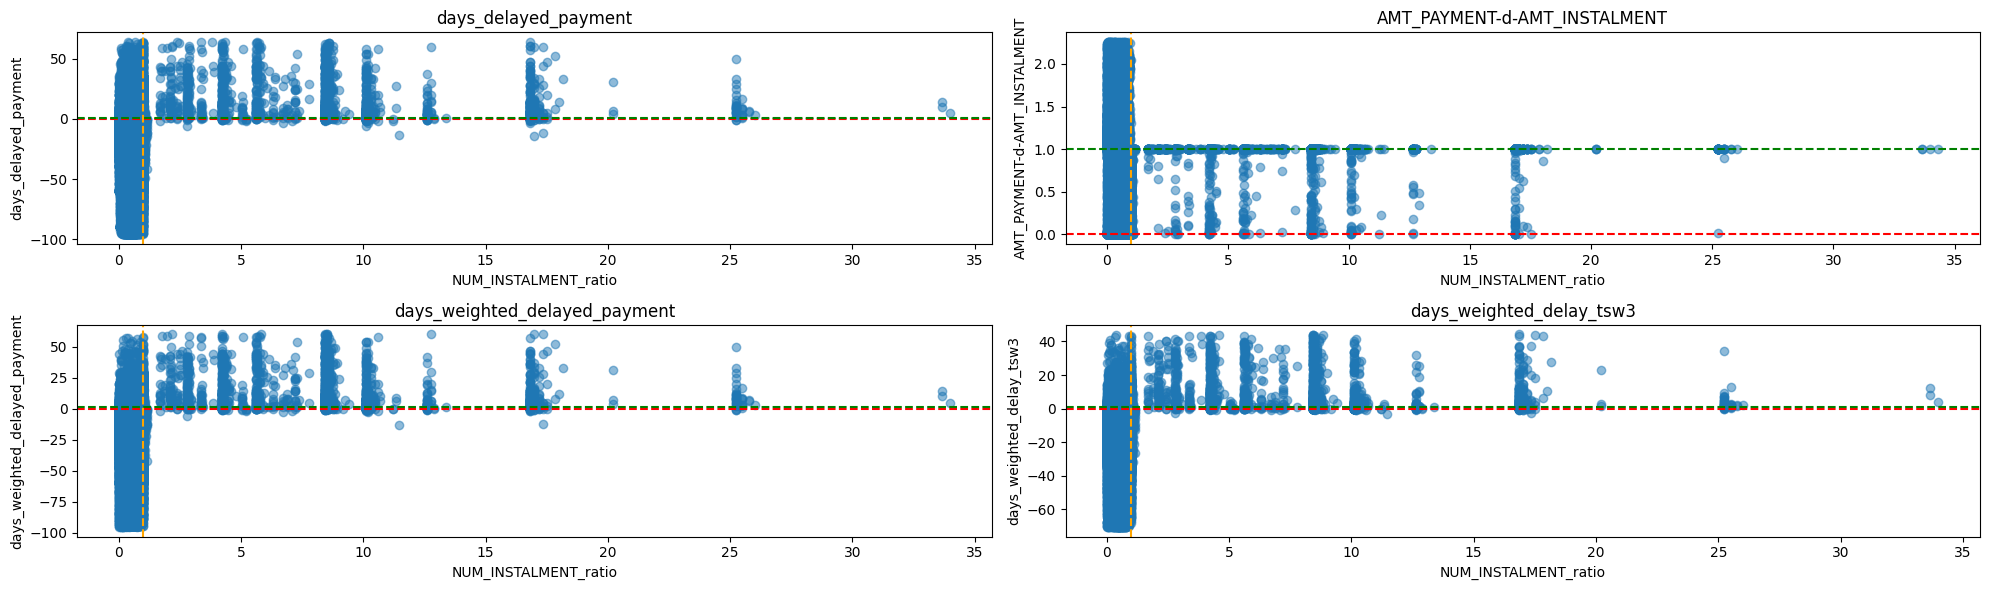

In [115]:
x_col = "NUM_INSTALMENT_ratio"
numeric_cols = ["days_delayed_payment", "AMT_PAYMENT-d-AMT_INSTALMENT", "days_weighted_delayed_payment", "days_weighted_delay_tsw3"]

n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows))
axes = axes.flatten()

for ax, y_col in zip(axes, numeric_cols):
    _tmp = tmp.dropna().sample(n=1000000, random_state=42)

    Q1 = _tmp[y_col].quantile(0.05)
    Q3 = _tmp[y_col].quantile(0.95)
    IQR = Q3 - Q1
    _tmp = _tmp[(_tmp[y_col] >= (Q1 - 1.5 * IQR)) & (_tmp[y_col] <= (Q3 + 1.5 * IQR))]  # không phải outlier nhưng tạm thời lấy khoảng tin cậy 95% để dễ nhìn
    ax.scatter(_tmp[x_col], _tmp[y_col], alpha=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.axhline(y=1, color='green', linestyle='--', linewidth=1.5)
    ax.axvline(x=1, color='orange', linestyle='--', linewidth=1.5)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{y_col}")

for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

* NUM_INSTALMENT_ratio > 1 delay rất nhiều
* NUM_INSTALMENT_ratio > 1 trả góp nhỏ hơn hoặc bằng INSTALMENT ban đầu (có thể là do parameter)

## xét số lượng payment cho một khoản vay

In [116]:
payment_counts = tmp.groupby("SK_ID_PREV").size().reset_index(name="count")

In [117]:
agg_cols = {
    "days_delayed_payment": ["mean", "max"], "days_weighted_delayed_payment": ["mean", "max"], "days_weighted_delay_tsw3": ["mean", "max"], "AMT_PAYMENT-d-AMT_INSTALMENT": ["mean", "max", "std"],
    "CNT_PAYMENT": "first"
}
payment_stats = tmp.groupby("SK_ID_PREV").agg(agg_cols).reset_index()
payment_stats.columns = ["_".join(col).rstrip("_") for col in payment_stats.columns]

In [118]:
payment_counts = payment_counts.merge(payment_stats, on="SK_ID_PREV", how="left")

In [119]:
payment_counts["CNT_PAYMENT_ratio"] = payment_counts["count"] / payment_counts["CNT_PAYMENT_first"]  # sử dụng trong aggr

In [120]:
payment_counts["AMT_PAYMENT-d-AMT_INSTALMENT_std"].max()  # không phải là outlier, nhưng tạm thời lấy khoảng tin cậy 95% để dễ xem biểu đồ

np.float64(96799.49999913912)

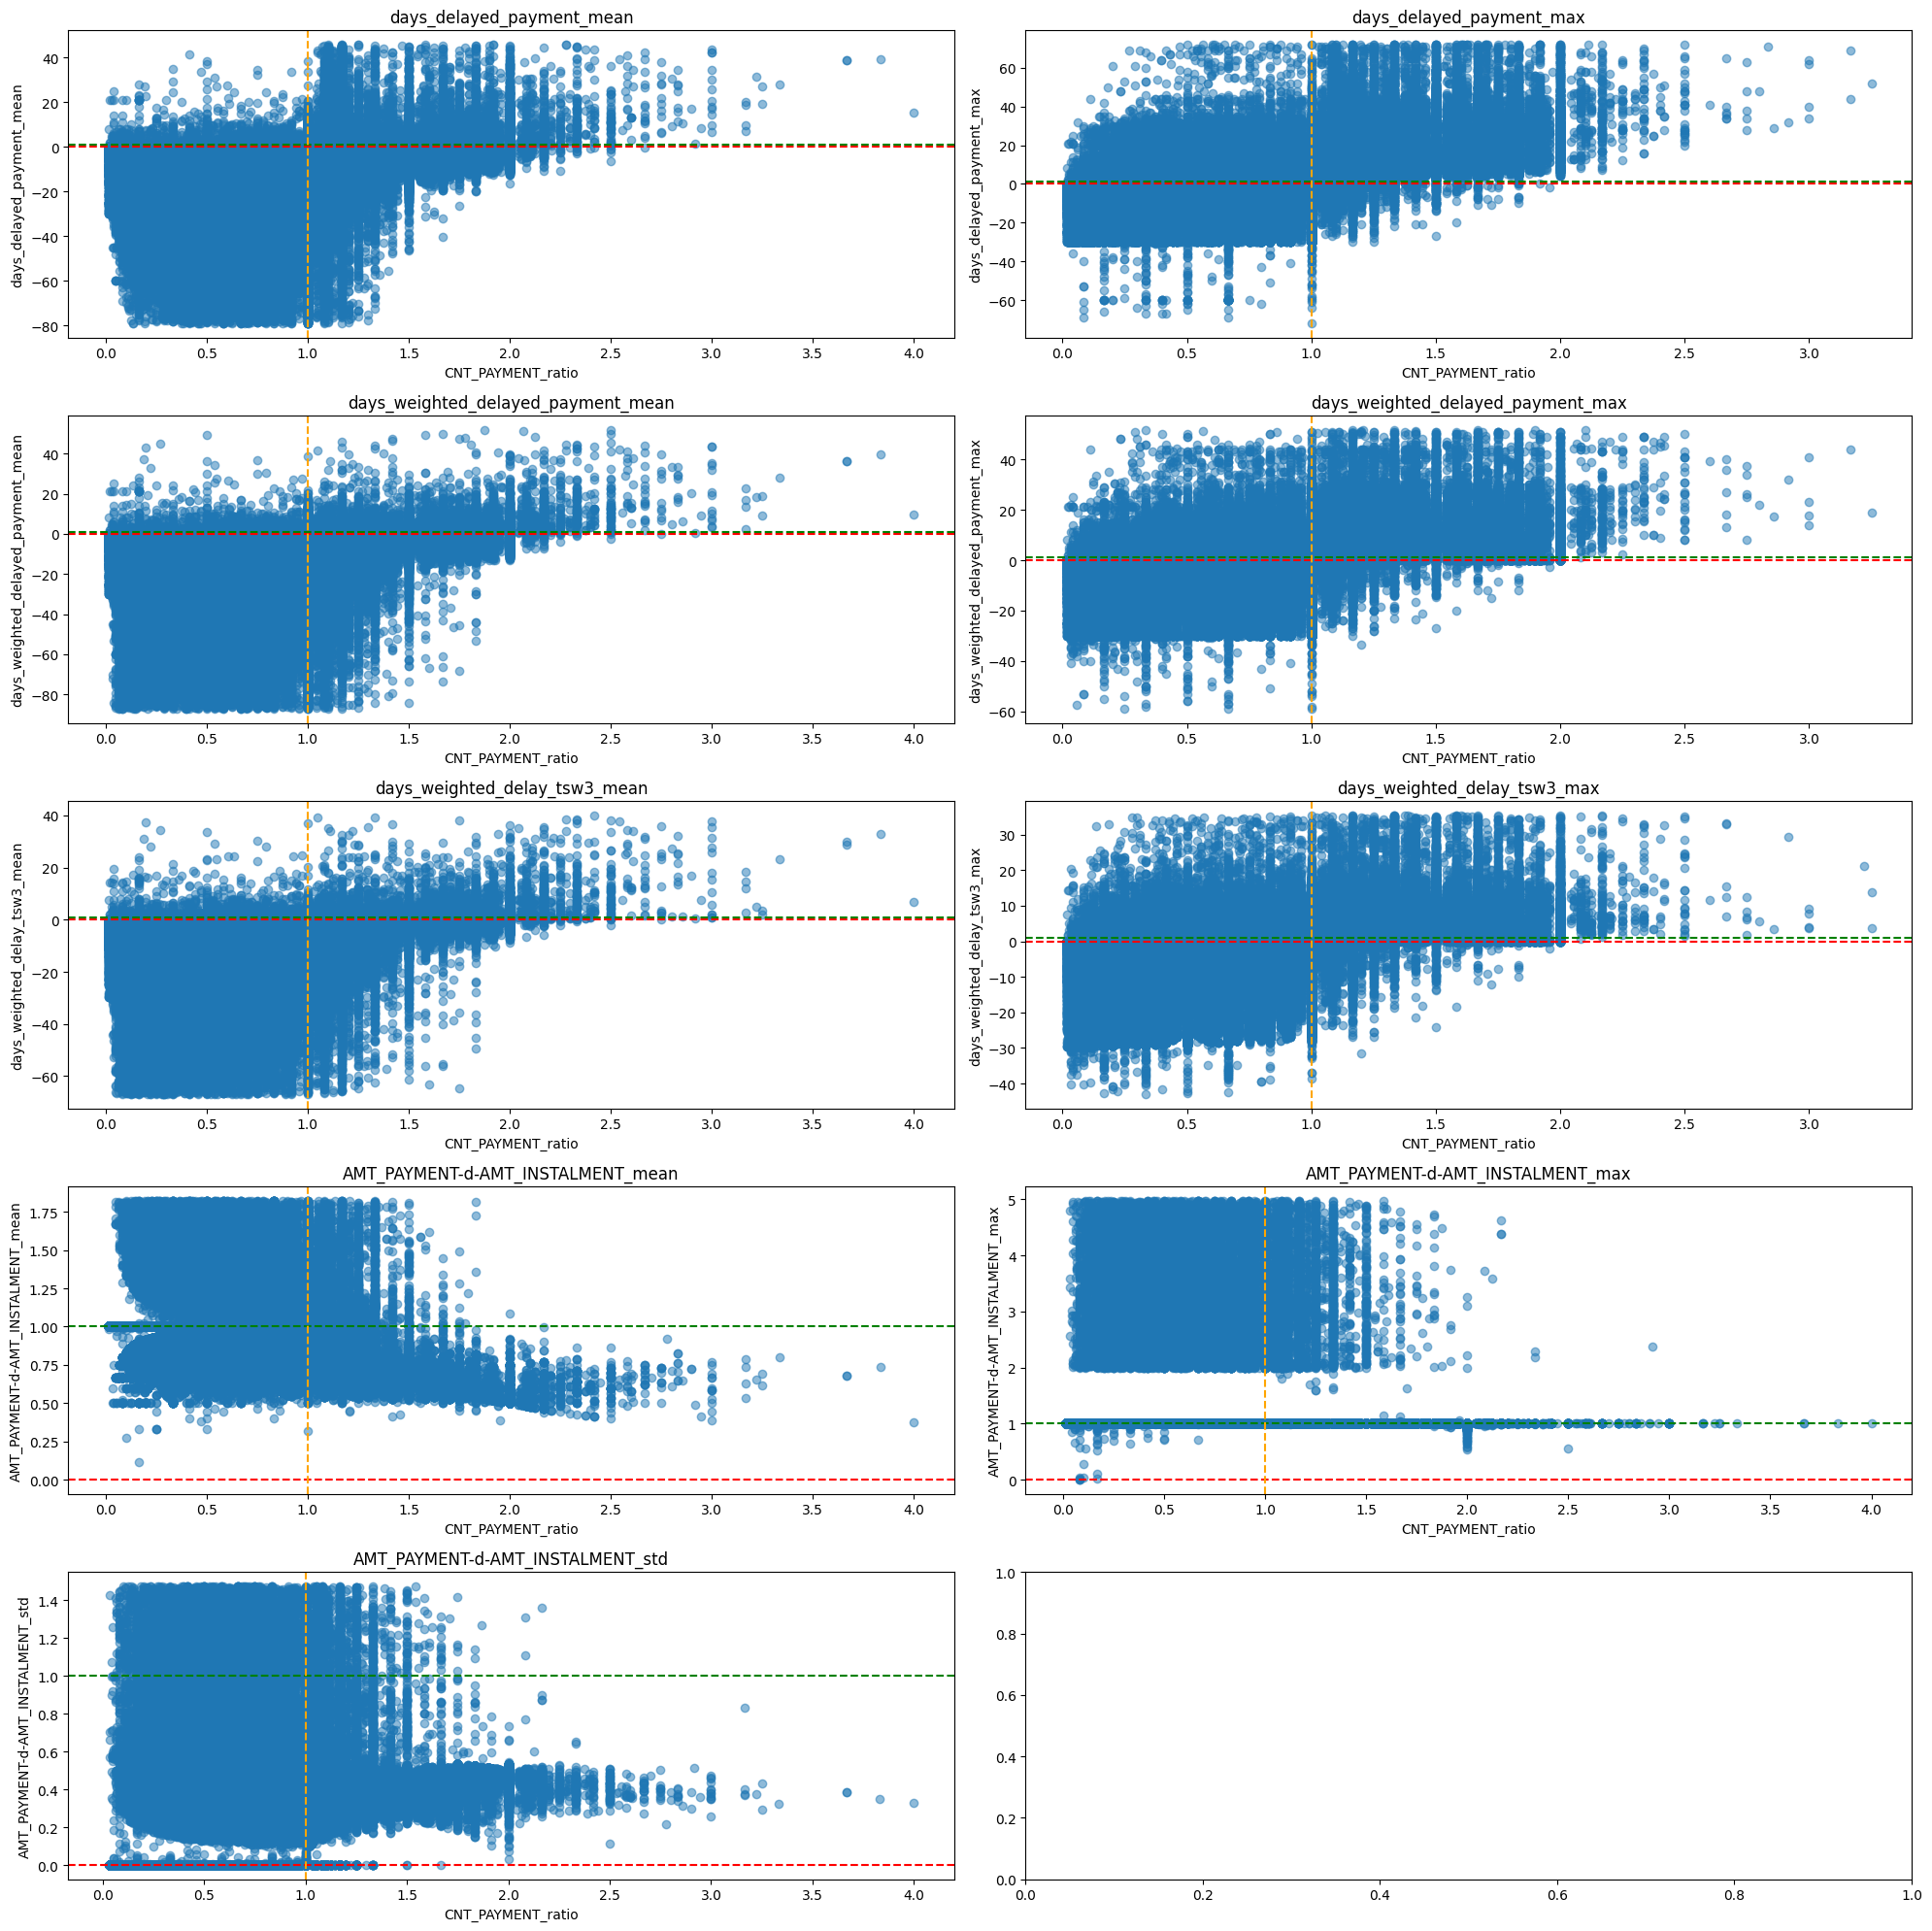

In [121]:
x_col = "CNT_PAYMENT_ratio"
numeric_cols = [
    "days_delayed_payment_mean", "days_delayed_payment_max", "days_weighted_delayed_payment_mean", "days_weighted_delayed_payment_max", "days_weighted_delay_tsw3_mean", "days_weighted_delay_tsw3_max",
    "AMT_PAYMENT-d-AMT_INSTALMENT_mean", "AMT_PAYMENT-d-AMT_INSTALMENT_max", "AMT_PAYMENT-d-AMT_INSTALMENT_std"
]

fig, axes = plt.subplots((len(numeric_cols) // 2) + 1, 2, figsize=(20, 5 * (len(numeric_cols) // 2)))
axes = axes.flatten()

for ax, y_col in zip(axes, numeric_cols):
    _tmp = payment_counts[[x_col, y_col]].dropna()

    Q1 = _tmp[y_col].quantile(0.05)
    Q3 = _tmp[y_col].quantile(0.95)
    IQR = Q3 - Q1
    _tmp = _tmp[(_tmp[y_col] >= (Q1 - 1.5 * IQR)) & (_tmp[y_col] <= (Q3 + 1.5 * IQR))]
    ax.scatter(_tmp[x_col], _tmp[y_col], alpha=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.axhline(y=1, color='green', linestyle='--', linewidth=1.5)
    ax.axvline(x=1, color='orange', linestyle='--', linewidth=1.5)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{y_col}")

plt.tight_layout()
plt.show()

* Trả nhiều lần có xu hướng delay nhiều hơn và xa ngày hết hạn hơn (delay > 0), ngược lại, trả góp gọn gàng hơn có xu hướng trả trước hạn (delay < 0)  có sự chuẩn bị tốt. (Lưu ý: bao gồm cả hồ sơ chưa đầy đủ do thời gian xét duyệt).
* Trả góp gọn gàng ít lần có xu hướng trả nhiều tiền hơn (PAYMENT/INSTALMENT >= 1). Lý do có thể là rút ngắn thời gian trả góp, giảm lãi suất,..... Ngược lại, trả góp càng nhỏ giọt lại có xu hướng trả thiếu tiền, chia ra thành nhiều lần trả (PAYMENT/INSTALMENT < 1)
* Độ lệch chuẩn ratio:
* * Trả góp nhỏ giọt: ~0.3 - 0.5. Có sự chênh lệch tỉ lệ khá lớn và chỉ tập trung nhiều vào khoảng [0.3, 0.5], điều này chứng minh khoản tiền trả góp không ổn định (có khoản vay sẽ trả 99%/1%, có những khoản vay trả góp rải rác tỉ lệ 30%/30%/20%/20%...)
* * Trả góp gọn gàng: trải dài từ 0 - 1.5. Sự chênh lệch này đến từ việc trả quá số tiền quy định khiến độ lệch chuẩn lớn. Những điểm bằng 0 là trả góp tiêu dùng đều đặn

In [146]:
_keep_vars.update({"payment_counts"})
cache_clear(globals(), _keep_vars)

# xét hành vi trả góp rủi ro / không rủi ro

In [123]:
tmp = pd.merge(tmp, train, on='SK_ID_CURR', how='left')

In [124]:
id = tmp[tmp["TARGET"] == 1]["SK_ID_CURR"].unique()

In [125]:
# SK_ID_CURR == 122418 là trường hợp đang xét
tmp[tmp["SK_ID_CURR"] == 122418].sort_values(["DAYS_ENTRY_PAYMENT"], ascending=[True])

,index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,days_delayed_payment,AMT_PAYMENT-s-AMT_INSTALMENT,AMT_PAYMENT-d-AMT_INSTALMENT,days_weighted_delayed_payment,days_weighted_delay_tsw3,DPD,DBD,CNT_PAYMENT,NUM_INSTALMENT_ratio,TARGET
13064037,13064037,2769417,122418,1.0,1,-2759,-2759.0,4459.230,4459.230,0.0,0.000,1.000000,0.000000,0.000000,0.0,0.0,9.0,0.111111,1.0
13064038,13064038,2769417,122418,1.0,2,-2729,-2741.0,4459.230,4459.230,-12.0,0.000,1.000000,-12.000000,-2.132400,0.0,12.0,9.0,0.222222,1.0
13064039,13064039,2769417,122418,1.0,3,-2699,-2717.0,4459.230,4459.230,-18.0,0.000,1.000000,-18.000000,-3.328200,0.0,18.0,9.0,0.333333,1.0
13064040,13064040,2769417,122418,1.0,4,-2669,-2675.0,4459.230,4459.230,-6.0,0.000,1.000000,-6.000000,-1.185000,0.0,6.0,9.0,0.444444,1.0
13064041,13064041,2769417,122418,1.0,5,-2639,-2646.0,4459.230,4459.230,-7.0,0.000,1.000000,-7.000000,-1.443400,0.0,7.0,9.0,0.555556,1.0
13064042,13064042,2769417,122418,1.0,6,-2609,-2625.0,4459.230,4459.230,-16.0,0.000,1.000000,-16.000000,-3.400000,0.0,16.0,9.0,0.666667,1.0
13064043,13064043,2769417,122418,1.0,7,-2579,-2583.0,4459.230,4459.230,-4.0,0.000,1.000000,-4.000000,-0.900400,0.0,4.0,9.0,0.777778,1.0
13064044,13064044,2769417,122418,1.0,8,-2549,-2560.0,4459.230,4459.230,-11.0,0.000,1.000000,-11.000000,-2.552000,0.0,11.0,9.0,0.888889,1.0
13064045,13064045,2769417,122418,1.0,9,-2519,-2525.0,4451.895,4451.895,-6.0,0.000,1.000000,-6.000000,-1.455000,0.0,6.0,9.0,1.000000,1.0
8659837,8659837,2154622,122418,1.0,2,-742,-756.0,16012.125,187.875,-14.0,-15824.250,0.011733,-0.164266,-0.127011,0.0,14.0,12.0,0.166667,1.0


"First few installments are more important than last installments. You know, it’s human nature. When loan applicant late once, he might be late from then. HC will want to make sure loan applicant is always on time from the beginning." (một số ít những khoản trả góp ban đầu quan trọng hơn những khoản cuối cùng. HC muốn make sure người vay sẽ luôn đúng hạn ngay từ đầu. nếu người vay đã muộn một lần thì khả năng cao các lần sau cũng sẽ muộn) -- https://www.kaggle.com/competitions/home-credit-default-risk/discussion/63032



TARGET
0.0    Axes(0.125,0.11;0.775x0.77)
1.0    Axes(0.125,0.11;0.775x0.77)
Name: days_delayed_payment, dtype: object

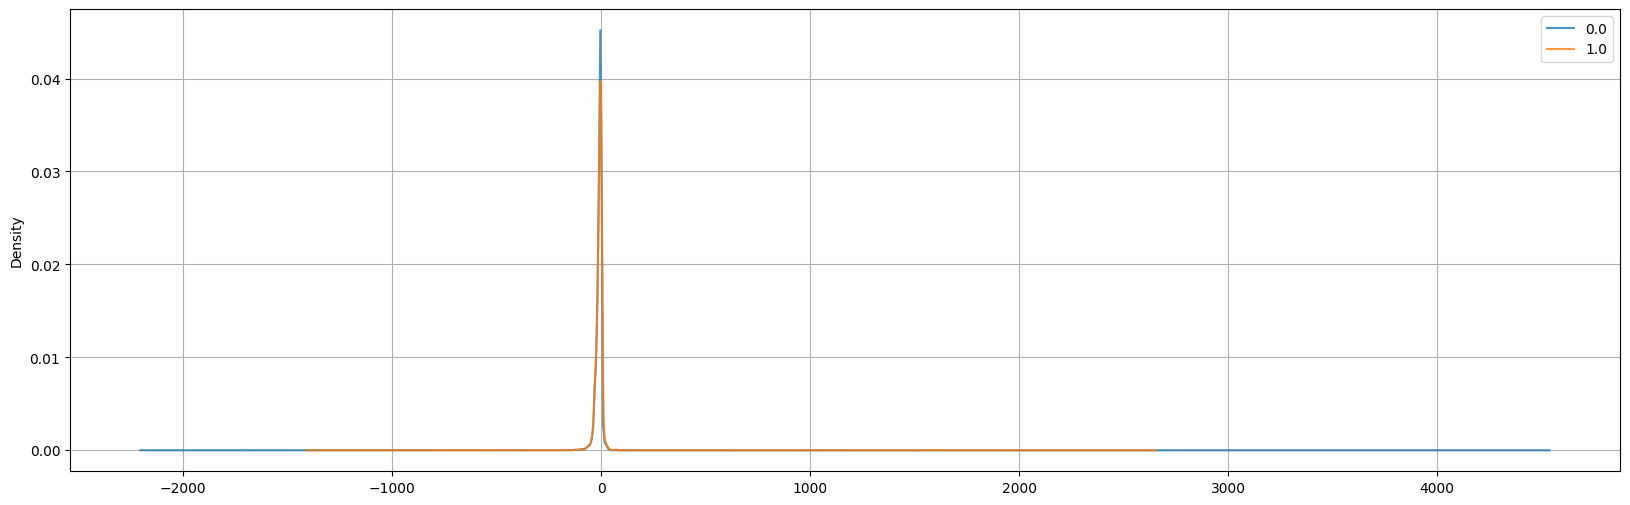

In [135]:
plt.figure(figsize=(20, 6))
tmp.sample(n=100000, random_state=42).groupby("TARGET")["days_delayed_payment"].plot(kind='kde', legend=True, alpha=0.8, grid=True)

TARGET
0.0    Axes(0.125,0.11;0.775x0.77)
1.0    Axes(0.125,0.11;0.775x0.77)
Name: AMT_PAYMENT-d-AMT_INSTALMENT, dtype: object

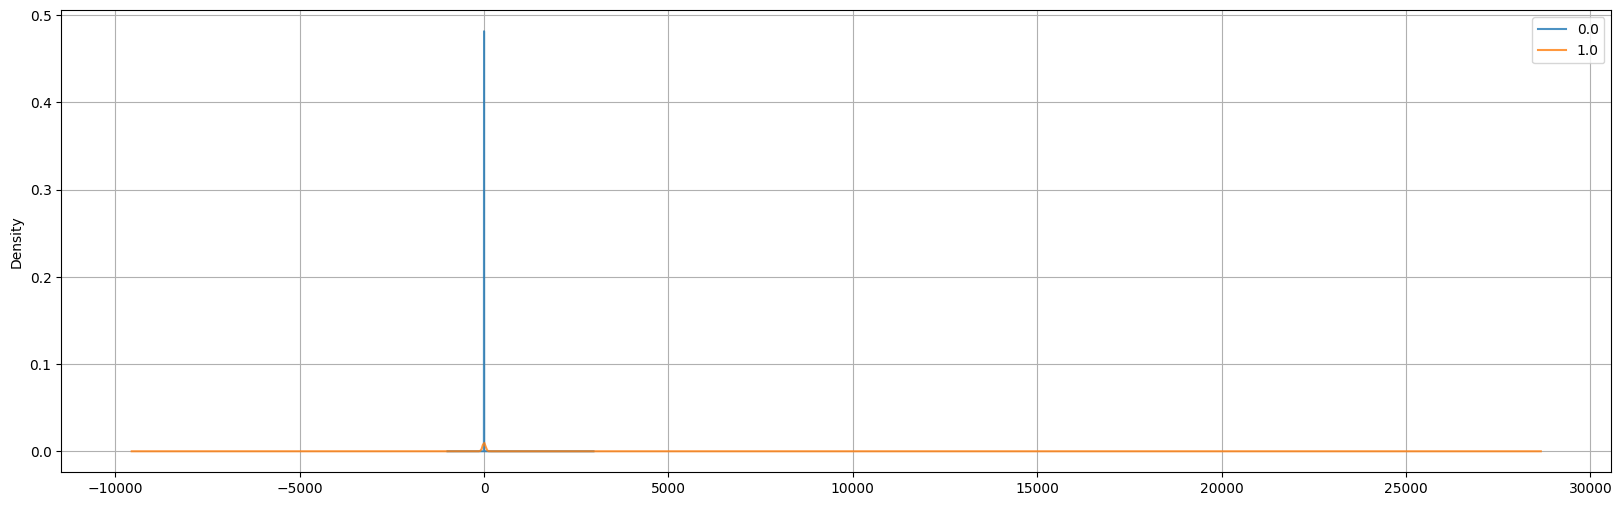

In [136]:
plt.figure(figsize=(20, 6))
tmp.sample(n=100000, random_state=42).groupby("TARGET")["AMT_PAYMENT-d-AMT_INSTALMENT"].plot(kind='kde', legend=True, alpha=0.8, grid=True)

* TARGET = 1 (hồ sơ rủi ro) có xu hướng trả rất nhiều so với ban đầu (trả dồn vào một vài lần), không ổn định vì miền giá trị (màu cam) trải dài
* TARGET = 0 (hồ sơ không rủi ro) có xu hướng trả trong khoảng xung quanh INSTALMENT, ổn định vì miền giá trị (màu xanh) ngắn

số tiền thực tế phải trả > số tiền vay tín dụng => tính được lãi suất interest rate (trong prev thì lãi suất đã bị chuẩn hóa)

TARGET
0.0    Axes(0.125,0.11;0.775x0.77)
1.0    Axes(0.125,0.11;0.775x0.77)
Name: NUM_INSTALMENT_ratio, dtype: object

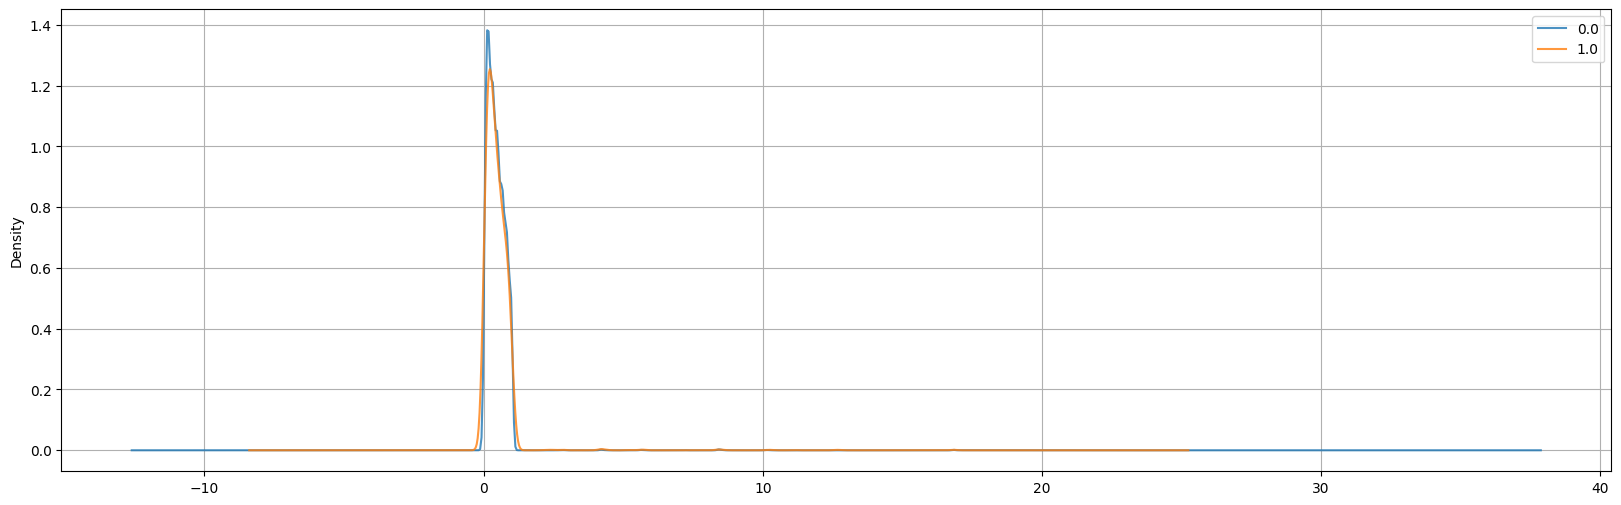

In [144]:
plt.figure(figsize=(20, 6))
tmp.sample(n=100000, random_state=42).groupby("TARGET")["NUM_INSTALMENT_ratio"].plot(kind='kde', legend=True, alpha=0.8, grid=True)

* Phân bổ đều chủ yếu trong khoảng (0, 1)
* Xuất hiện những ratio > 1 (version thay đổi, NUM_INSTALMENT có dạng 10x)

In [154]:
payment_counts = payment_counts.merge(prev[["SK_ID_PREV", "SK_ID_CURR"]], on="SK_ID_PREV", how="left")

In [158]:
payment_counts = payment_counts.merge(train, on="SK_ID_CURR", how="left")

TARGET
0.0    Axes(0.125,0.11;0.775x0.77)
1.0    Axes(0.125,0.11;0.775x0.77)
Name: CNT_PAYMENT_ratio, dtype: object

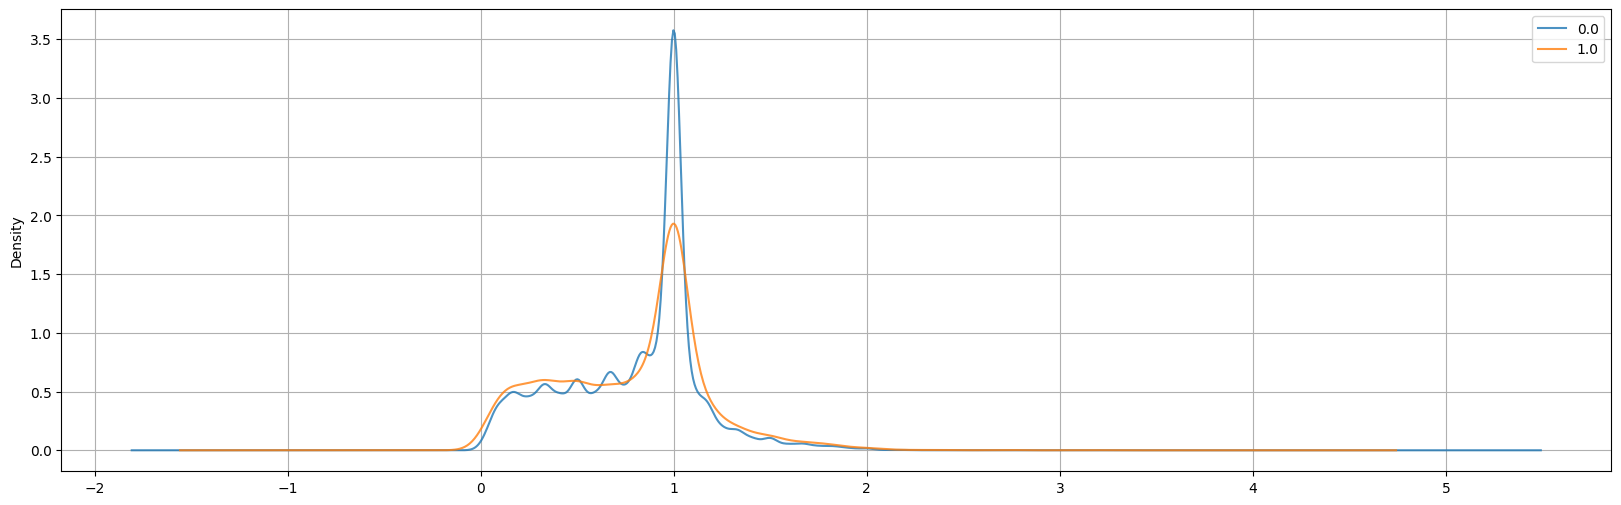

In [161]:
plt.figure(figsize=(20, 6))
payment_counts.sample(n=100000, random_state=42).groupby("TARGET")["CNT_PAYMENT_ratio"].plot(kind='kde', legend=True, alpha=0.8, grid=True)  # .sample(n=100000, random_state=42)

* Hồ sơ không rủi ro có xu hướng trả góp đúng số lần quy định hơn
* Tỉ lệ trả nhiều hơn hay ít hơn CNT_PAYMENT khá đồng đều

In [181]:
cache_clear(globals())

# xét thể loại trả góp (tín dụng hoặc trả góp tiêu dùng)

* NUM_INSTALMENT_VERSION = 0 <=> Revolving loans (Vay tín dụng xoay vòng, do vậy số tiền phải trả hàng tháng là không cố định. Tuy nhiên người dùng có xu hướng tiêu dùng dưới hoặc bằng hạn mức tín dụng, do vậy nên chỉ cần trả số tiền lãi tối thiểu)
* Số lượng vay tín dụng xoay vòng trong bộ dữ liệu này khá ít (vì là của Home Credit - Việt Nam và các nước DNA)

* instalment[AMT_INSTALMENT] <=> prev[AMT_ANNUITY]

In [204]:
tmp_2.head()

,index,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,days_delayed_payment,AMT_PAYMENT-s-AMT_INSTALMENT,AMT_PAYMENT-d-AMT_INSTALMENT,days_weighted_delayed_payment,days_weighted_delay_tsw3,DPD,DBD,CNT_PAYMENT,NUM_INSTALMENT_ratio,TARGET,revolving_loan
0,0,1000001,158271,1.0,1,-268,-294.0,6404.310,6404.310,-26.0,0.0,1.0,-26.0,-23.7068,0.0,26.0,12.0,0.083333,0.0,True
1,1,1000001,158271,2.0,2,-238,-244.0,62039.115,62039.115,-6.0,0.0,1.0,-6.0,-5.5608,0.0,6.0,12.0,0.166667,0.0,True
2,2,1000002,101962,1.0,1,-1600,-1611.0,6264.000,6264.000,-11.0,0.0,1.0,-11.0,-5.6837,0.0,11.0,6.0,0.166667,NaN,True
3,3,1000002,101962,1.0,2,-1570,-1575.0,6264.000,6264.000,-5.0,0.0,1.0,-5.0,-2.6375,0.0,5.0,6.0,0.333333,NaN,True
4,4,1000002,101962,1.0,3,-1540,-1559.0,6264.000,6264.000,-19.0,0.0,1.0,-19.0,-10.1137,0.0,19.0,6.0,0.500000,NaN,True


In [201]:
tmp_2 = tmp.copy()

In [211]:
tmp_2["revolving_loan"] = tmp_2["NUM_INSTALMENT_VERSION"] == 0

revolving_loan
False    Axes(0.125,0.11;0.775x0.77)
True     Axes(0.125,0.11;0.775x0.77)
Name: AMT_PAYMENT-d-AMT_INSTALMENT, dtype: object

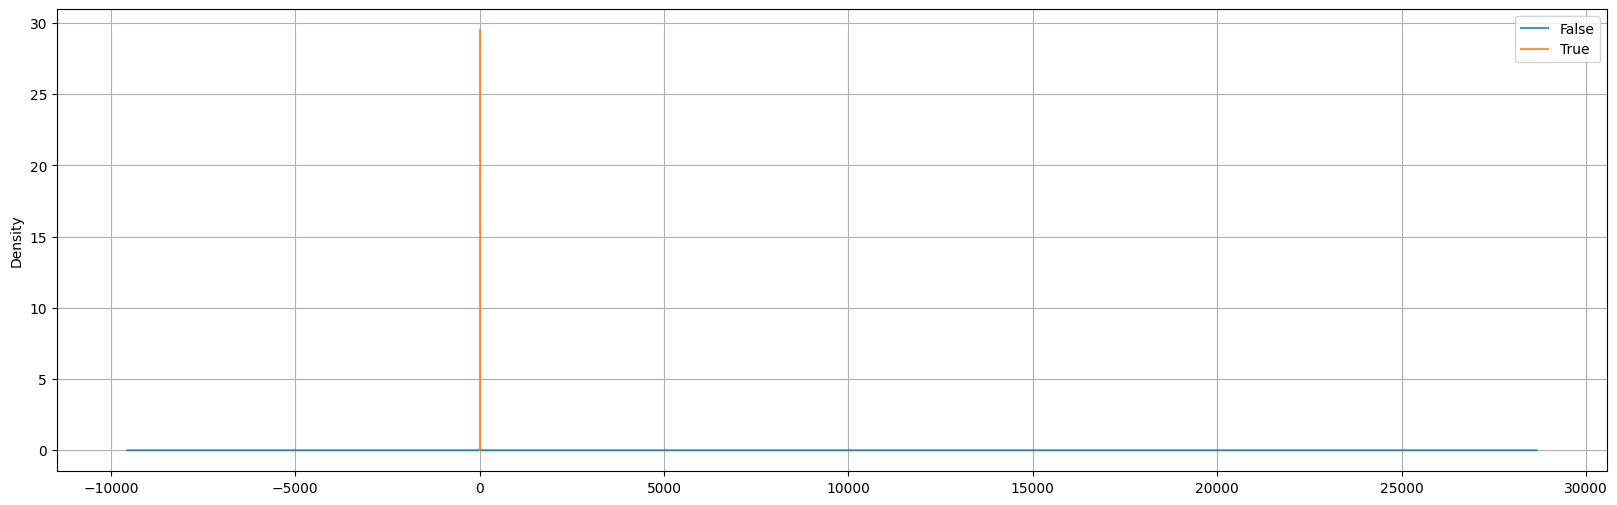

In [212]:
plt.figure(figsize=(20, 6))
tmp_2.sample(n=100000, random_state=42).groupby("revolving_loan")["AMT_PAYMENT-d-AMT_INSTALMENT"].plot(kind='kde', legend=True, alpha=0.8, grid=True)

* Trả góp cho khoản vay tín dụng có xu hướng không đồng đều, ngược lại trả góp tiêu dùng

revolving_loan
False    Axes(0.125,0.11;0.775x0.77)
Name: NUM_INSTALMENT_ratio, dtype: object

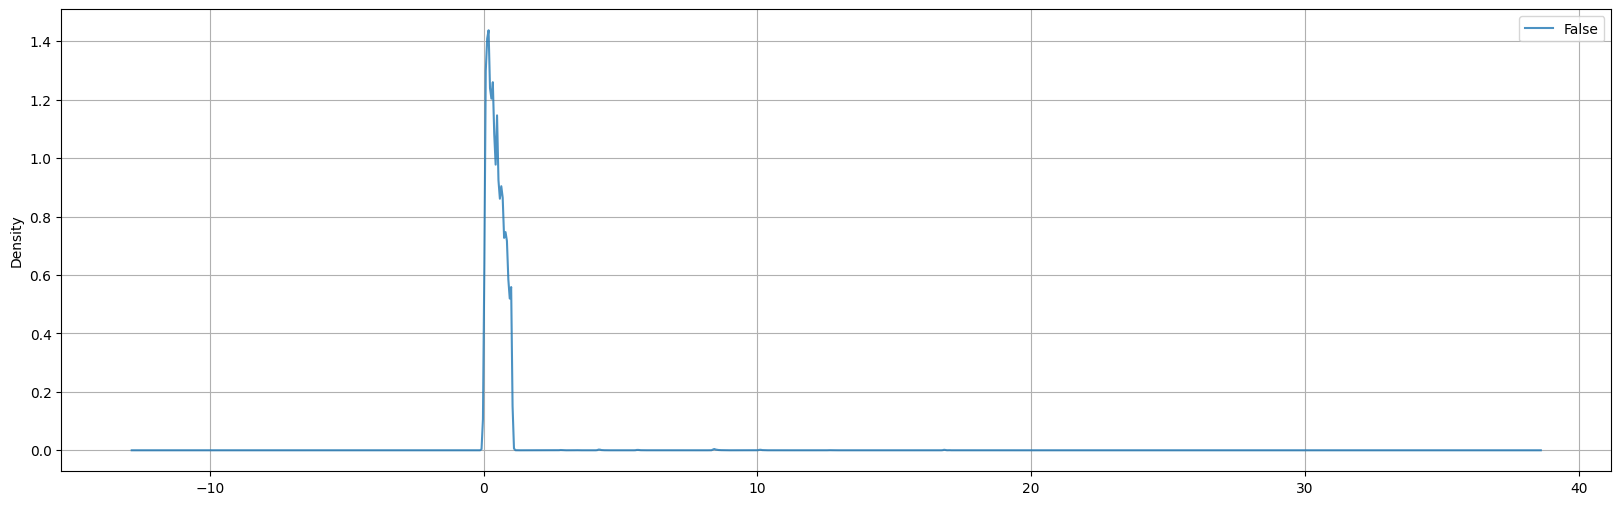

In [214]:
plt.figure(figsize=(20, 6))
tmp_2.sample(n=1000000, random_state=42).dropna().groupby("revolving_loan")["NUM_INSTALMENT_ratio"].plot(kind='kde', legend=True, alpha=0.8, grid=True)  # NUM_INSTALMENT_ratio

* Trả góp không có số ngày phải trả (CNT_PAYMENT = null)